In [1]:
import math
import torch
import numpy as np
from matplotlib import pyplot as plt

@torch.no_grad()
def make_ring(
    N: int,
    threshold_active_fraction: float,
    g_disorder: float = 0.00,
    device: str = "cpu",
    seed: int | None = 0,
) -> torch.Tensor:
    """
    Returns W (N,N): structured local ring kernel + symmetric Gaussian disorder.
    Matches your construction:
      K_ij = 1/N if ring distance <= threshold else 0, with K_ii=0
      J_dis_ij ~ N(0, g^2/(2N)) symmetric, with zero diagonal
    """
    if seed is not None:
        torch.manual_seed(seed)

    idx = torch.arange(N, device=device)
    diff = (idx[:, None] - idx[None, :]).abs()
    diff = torch.minimum(diff, N - diff)

    thr = threshold_active_fraction * N / 2.0
    K = (diff <= thr).float() / N
    K.fill_diagonal_(0.0)

    R = torch.randn((N, N), device=device)
    R = torch.triu(R, diagonal=1)
    R = R + R.T
    R.fill_diagonal_(0.0)

    J_dis = (g_disorder / math.sqrt(2.0 * N)) * R

    W = K + J_dis
    W.fill_diagonal_(0.0)
    return W


@torch.no_grad()
def ring_gaussian_bump(N: int, center: float, width: float, amp: float, device="cpu") -> torch.Tensor:
    """
    center in [0, N), width in neuron-index units.
    Uses periodic distance on the ring.
    """
    idx = torch.arange(N, device=device).float()
    d = (idx - center).abs()
    d = torch.minimum(d, N - d)
    return amp * torch.exp(-0.5 * (d / width) ** 2)

@torch.no_grad()
def lam_max_effective(W: torch.Tensor, s: torch.Tensor, T: float, c: float, eps: float = 1e-12):
    """
    Diagnostic: lam_max of M = (c/T) * D W, D=rho(1-rho)/T.
    lam_max -> 1 means near-marginal χ.
    """
    D_matrix = torch.diag(s)
    M = (c) * (D_matrix @ W)
    lam = float(torch.linalg.eigvalsh(M).max().item())
    return lam

@torch.no_grad()
def Chi_from_s(W: torch.Tensor, s: torch.Tensor, c: float,
                    eps: float = 1e-8) -> torch.Tensor:
    """
    Equilibrium/FDT covariance :
    """
    N = W.shape[0]
    device = W.device

    D_matrix = torch.diag(s)
    M = torch.eye(N, device=device) - c * (D_matrix@ W)
    X = torch.linalg.solve(M, D_matrix)     # (I-M)^{-1} D

    return X

def make_static_thresholds(
    N: int,
    sigma_theta: float = 0.05,
    device: str = "cpu",
    seed: int | None = 0,
):
    """
    Fixed neuron-specific threshold offsets theta_i.
    Mean-centered so eta controls the global mean separately.
    """
    g = torch.Generator(device=device)
    if seed is not None:
        g.manual_seed(seed)
    theta = sigma_theta * torch.randn(N, generator=g, device=device)
    theta = theta - theta.mean()
    return theta

# ------------------------------------------------------------
# Simple diagnostics
# ------------------------------------------------------------
def weak_fraction_from_dmu(dmu: torch.Tensor, low=1e-4, high=0.02):
    """
    Fraction of neurons with small but nonzero tuning.
    """
    ad = dmu.abs()
    return ((ad > low) & (ad < high)).float().mean().item()

def participation_ratio(vec: torch.Tensor, eps: float = 1e-12):
    x2 = (vec**2).sum()
    x4 = (vec**4).sum()
    return float((x2**2 / (x4 + eps)).item())


@torch.no_grad()
def output_function(mu1c, mu2c, mu1f, mu2f, x1, x2, uarray_ctr, uarray_fr, energy_ctr, energy_fr, W, T, c_ctr, c_fr, sigma0, eta_std, u0, du,b,db,theta_ctr, theta_fr):
    ctr_color = "royalblue"
    fr_color = "crimson"
    top_k = 10

    def _cpu(x):
        return x.detach().cpu()

    def _mode_projection(evecs, signal_vec):
        return (evecs.T @ signal_vec).pow(2)

    def _top_alignment(evals, evecs, signal_vec, k):
        signal_unit = signal_vec / (signal_vec.norm() + 1e-12)
        order = torch.argsort(evals, descending=True)
        coeffs = evecs[:, order].T @ signal_unit
        return float((coeffs[:k] ** 2).sum().item())

    dmu_c = mu1c - mu2c
    dmu_f = mu1f - mu2f

    dx = x1 - x2
    g_ctr = gain_from_v(uarray_ctr, T=T, c=c_ctr, b=b, db=db,
                    eta_std=eta_std, sigma0=sigma0, u0=u0, du=du, theta=theta_ctr)
    g_fr = gain_from_v(uarray_fr, T=T, c=c_fr, b=b, db=db,
                    eta_std=eta_std, sigma0=sigma0, u0=u0, du=du, theta=theta_fr)
    
    sigma_ctr = Chi_from_s(W,g_ctr , c=c_ctr) * T
    sigma_fr = Chi_from_s(W,g_fr , c=c_fr) * T

    evals_ctr, evecs_ctr = torch.linalg.eigh(sigma_ctr)
    evals_fr, evecs_fr = torch.linalg.eigh(sigma_fr)
    overlap = torch.abs(evecs_ctr.T @ evecs_fr)

    proj_ctr = _mode_projection(evecs_ctr, dx)
    proj_fr = _mode_projection(evecs_fr, dx)
    signal_ctr = (evals_ctr ** 2) * proj_ctr
    signal_fr = (evals_fr ** 2) * proj_fr

    dmu_norm_est_ctr = float((c_ctr * ((sigma_ctr / T) @ dx)).norm().item())
    dmu_norm_est_fr = float((c_fr * ((sigma_fr / T) @ dx)).norm().item())

    lam_max_ctr = float(lam_max_effective(W, g_ctr, T=T, c=c_ctr))
    lam_max_fr = float(lam_max_effective(W, g_fr, T=T, c=c_fr))
    true_signal_ratio = float(torch.sqrt((c_fr**2 * signal_fr.sum()) / (c_ctr**2 * signal_ctr.sum())).item())

    summary = {
        "CTR": {
            "mean_rate": float(mu1c.mean().item()),
            "dmu_norm": float(dmu_c.norm().item()),
            "participation_ratio": float(participation_ratio(dmu_c)),
            "weak_fraction": float(weak_fraction_from_dmu(dmu_c)),
            "sigma_trace": float(sigma_ctr.trace().item()),
            "lr_estimate": dmu_norm_est_ctr,
            "lam_max": lam_max_ctr,
            "top_mode_alignment": _top_alignment(evals_ctr, evecs_ctr, dmu_c, top_k),
            "Energy": energy_ctr,
            
        },
        "FR": {
            "mean_rate": float(mu1f.mean().item()),
            "dmu_norm": float(dmu_f.norm().item()),
            "participation_ratio": float(participation_ratio(dmu_f)),
            "weak_fraction": float(weak_fraction_from_dmu(dmu_f)),
            "sigma_trace": float(sigma_fr.trace().item()),
            "lr_estimate": dmu_norm_est_fr,
            "lam_max": lam_max_fr,
            "top_mode_alignment": _top_alignment(evals_fr, evecs_fr, dmu_f, top_k),
            "Energy": energy_fr,
        },
        "true_signal_ratio": true_signal_ratio,
    }

    fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)

    ax = axes[0, 0]
    ax.plot(_cpu(mu1c), color=ctr_color, lw=2, label="CTR stim 1")
    # ax.plot(_cpu(mu2c), color=ctr_color, lw=1.5, ls="--", alpha=0.7, label="CTR stim 2")
    ax.plot(_cpu(mu1f), color=fr_color, lw=2, label="FR stim 1")
    # ax.plot(_cpu(mu2f), color=fr_color, lw=1.5, ls="--", alpha=0.7, label="FR stim 2")
    ax.set_title("Tuning curves")
    ax.set_xlabel("Neuron index")
    ax.set_ylabel("Rate")
    ax.grid(alpha=0.25, linestyle=":")
    ax.legend(frameon=False, ncol=2)

    ax = axes[0, 1]
    ax.plot(_cpu(dmu_c), color=ctr_color, lw=2, label="CTR dmu")
    ax.plot(_cpu(dmu_f), color=fr_color, lw=2, label="FR dmu")
    ax.set_title("Signal vectors")
    ax.set_xlabel("Neuron index")
    ax.set_ylabel("Delta rate")
    ax.grid(alpha=0.25, linestyle=":")
    ax.legend(frameon=False)

    ax = axes[1, 0]
    max_eval = float(torch.max(torch.stack([evals_ctr.max(), evals_fr.max()])).item())
    ax.scatter(_cpu(evals_ctr), _cpu(evals_fr), s=22, color="forestgreen", alpha=0.8)
    ax.plot([0.0, max_eval], [0.0, max_eval], color="0.5", ls="--", lw=1)
    ax.set_title("Covariance eigenvalues: CTR vs FR")
    ax.set_xlabel("CTR eigenvalue")
    ax.set_ylabel("FR eigenvalue")
    ax.grid(alpha=0.25, linestyle=":")

    ax = axes[1, 1]
    im = ax.imshow(_cpu(overlap), aspect="auto", origin="lower", cmap="viridis")
    ax.set_title("Eigenvector overlap")
    ax.set_xlabel("FR mode")
    ax.set_ylabel("CTR mode")
    fig.colorbar(im, ax=ax, shrink=0.85)

    plt.show()

    fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

    ax = axes[0, 0]
    ax.scatter(_cpu(evals_ctr), _cpu(proj_ctr), s=18, color=ctr_color, alpha=0.85)
    ax.set_title("CTR: mode projection")
    ax.set_xlabel("Eigenvalue")
    ax.set_ylabel("Projection")
    ax.grid(alpha=0.25, linestyle=":")

    ax = axes[0, 1]
    ax.scatter(_cpu(evals_ctr), _cpu(signal_ctr), s=18, color=ctr_color, alpha=0.85)
    ax.set_title("CTR: signal contribution")
    ax.set_xlabel("Eigenvalue")
    ax.set_ylabel("Contribution")
    ax.grid(alpha=0.25, linestyle=":")

    ax = axes[1, 0]
    ax.scatter(_cpu(evals_fr), _cpu(proj_fr), s=18, color=fr_color, alpha=0.85)
    ax.set_title("FR: mode projection")
    ax.set_xlabel("Eigenvalue")
    ax.set_ylabel("Projection")
    ax.grid(alpha=0.25, linestyle=":")

    ax = axes[1, 1]
    ax.scatter(_cpu(evals_fr), _cpu(signal_fr), s=18, color=fr_color, alpha=0.85)
    ax.set_title("FR: signal contribution")
    ax.set_xlabel("Eigenvalue")
    ax.set_ylabel("Contribution")
    ax.grid(alpha=0.25, linestyle=":")


    uarray_ctr = np.asarray(uarray_ctr, dtype=float)#/T
    uarray_fr = np.asarray(uarray_fr, dtype=float)#/T
    bins = np.linspace(min(uarray_ctr.min(), uarray_fr.min()), max(uarray_ctr.max(), uarray_fr.max()), 31)

    fig, ax1 = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
    ax1.hist(uarray_ctr, bins=bins, density=True, alpha=0.45, color=ctr_color, label=f"CTR mean drive v (mean={uarray_ctr.mean():.4f})")
    ax1.hist(uarray_fr, bins=bins, density=True, alpha=0.45, color=fr_color, label=f"FR mean drive v (mean={uarray_fr.mean():.4f})")
    ax1.axvline(uarray_ctr.mean(), color=ctr_color, ls="--", lw=1.5)
    ax1.axvline(uarray_fr.mean(), color=fr_color, ls="--", lw=1.5)
    ax1.set_title("Mean drive distribution")
    ax1.set_xlabel("Mean drive v")
    ax1.set_ylabel("Density")
    ax1.grid(alpha=0.2, linestyle=":")

    v_vals = torch.linspace(float(bins[0]), float(bins[-1]), 300)
    sigma_vals = sigma0 + eta_std * torch.nn.functional.softplus((v_vals - u0) / du)
    ax2 = ax1.twinx()
    ax2.plot(_cpu(v_vals), _cpu(sigma_vals), color="black", ls="--", lw=1.5, label="sigma(v)")
    ax2.set_ylabel("Noise scale")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, loc="upper right")
    plt.show()
    plt.plot(_cpu(evals_fr).flatten()/_cpu(evals_ctr).flatten())

    print("Summary metrics")
    print(f"{'metric':<22}{'CTR':>12}{'FR':>12}")
    print("-" * 46)
    rows = [
        ("mean rate", summary["CTR"]["mean_rate"], summary["FR"]["mean_rate"], ".4f"),
        ("Energy", summary["CTR"]["Energy"], summary["FR"]["Energy"], ".4f"),
        ("||dmu||", summary["CTR"]["dmu_norm"], summary["FR"]["dmu_norm"], ".4f"),
        ("LR estimate", summary["CTR"]["lr_estimate"], summary["FR"]["lr_estimate"], ".4f"),
        ("PR(dmu)", summary["CTR"]["participation_ratio"], summary["FR"]["participation_ratio"], ".2f"),
        ("weak fraction", summary["CTR"]["weak_fraction"], summary["FR"]["weak_fraction"], ".4f"),
        ("trace(sigma)", summary["CTR"]["sigma_trace"], summary["FR"]["sigma_trace"], ".4f"),
        ("lam_max", summary["CTR"]["lam_max"], summary["FR"]["lam_max"], ".4f"),
        (f"top-{top_k} alignment", summary["CTR"]["top_mode_alignment"], summary["FR"]["top_mode_alignment"], ".4f"),
    ]
    for label, ctr_val, fr_val, fmt in rows:
        print(f"{label:<22}{format(ctr_val, fmt):>12}{format(fr_val, fmt):>12}")
    print(f"{'true signal ratio':<22}{format(summary['true_signal_ratio'], '.4f'):>24}")

    return {
        "summary": summary,
        "eigenvalues": {"CTR": evals_ctr, "FR": evals_fr},
        "overlap": overlap,
        "projection": {"CTR": proj_ctr, "FR": proj_fr},
        "signal_contribution": {"CTR": signal_ctr, "FR": signal_fr},
    }

@torch.no_grad()
def gain_from_v(v, *, T, c, b, db, eta_std, sigma0, u0, du, theta=None, gh_points=32):
    device, dtype = v.device, v.dtype
    if theta is None:
        theta = torch.zeros_like(v)
    else:
        theta = torch.as_tensor(theta, device=device, dtype=dtype)

    b = torch.as_tensor(b, device=device, dtype=dtype)
    if c == 1.0:
        r = 1.0
        b_eff = b
    else:
        r = 1.27
        b_eff = b + db

    gh_x, gh_w = np.polynomial.hermite.hermgauss(gh_points)
    z = math.sqrt(2.0) * torch.tensor(gh_x, device=device, dtype=dtype)
    w = torch.tensor(gh_w, device=device, dtype=dtype)
    norm = 1.0 / math.sqrt(math.pi)

    u = v - theta + b_eff
    sigma_u = sigma0 + eta_std * torch.nn.functional.softplus((v - u0) / du)
    dsigma_dv = (eta_std / du) * torch.sigmoid((v - u0) / du)

    field = (u[..., None] + r * sigma_u[..., None] * z) / T
    p = torch.sigmoid(field)

    g = norm * torch.sum(
        w * p * (1.0 - p) * (1.0 + r * z * dsigma_dv[..., None]) / T,
        dim=-1,
    )
    return g




In [2]:

@torch.no_grad()
def mean_field_transfer_from_v(
    v,
    *,
    T: float,
    c: float,
    b: float | torch.Tensor = -0.09,
    db: float = 0.01,
    eta_std: float = 0.1,
    sigma0: float = 0.003,
    u0: float = -0.01,
    du: float = 0.01,
    theta: torch.Tensor | None = None,
    gh_points: int = 32,
    device: str | torch.device | None = None,
    dtype: torch.dtype | None = None,
):
    if isinstance(v, torch.Tensor):
        if device is None:
            device = v.device
        if dtype is None:
            dtype = v.dtype
    else:
        if device is None:
            device = "cpu"
        if dtype is None:
            dtype = torch.float64

    v = torch.as_tensor(v, device=device, dtype=dtype)
    b = torch.as_tensor(b, device=device, dtype=dtype)
    if theta is None:
        theta = torch.zeros((), device=device, dtype=dtype)
    else:
        theta = torch.as_tensor(theta, device=device, dtype=dtype)

    if c == 1.0:
        r = 1.0
        b_eff = b
    else:
        r = 1.27
        b_eff = b + db

    gh_x, gh_w = np.polynomial.hermite.hermgauss(gh_points)
    gh_x = torch.tensor(gh_x, device=device, dtype=dtype)
    gh_w = torch.tensor(gh_w, device=device, dtype=dtype)

    z = math.sqrt(2.0) * gh_x
    norm = 1.0 / math.sqrt(math.pi)

    u = v - theta + b_eff
    sigma_u = sigma0 + eta_std * torch.nn.functional.softplus((v - u0) / du)
    field = (u[..., None] + r * sigma_u[..., None] * z) / T
    rho = norm * torch.sum(gh_w * torch.sigmoid(field), dim=-1)

    return {
        "rho": rho,
        "u": u,
        "sigma_u": sigma_u,
        "r": r,
        "b_eff": b_eff,
    }


@torch.no_grad()
def mean_field_operating_point(
    J: torch.Tensor,
    rho: torch.Tensor,
    x: torch.Tensor,
    *,
    c: float,
    T: float,
    b: float = -0.09,
    I: float = 0.0301,
    eta_std: float = 0.1,
    sigma0: float = 0.003,
    u0: float = -0.01,
    du: float = 0.01,
    db: float = 0.01,
    theta: torch.Tensor | None = None,
    gh_points: int = 32,
):
    device = J.device
    dtype = J.dtype

    rho = rho.to(device=device, dtype=dtype)
    x = x.to(device=device, dtype=dtype)
    if I is None:
        I_scalar = torch.as_tensor(0.0301, device=device, dtype=dtype)
    else:
        I_scalar = torch.as_tensor(I, device=device, dtype=dtype)
    if I_scalar.numel() != 1:
        raise ValueError("I must be a scalar.")
    I_scalar = I_scalar.reshape(())
    h = J @ rho
    # Current convention: recenter I to the population-mean drive.
    # Comment out the next line to use the passed scalar I instead.
    I_scalar = (h + x).mean()
    v = c * (h + x - I_scalar)
    transfer = mean_field_transfer_from_v(
        v,
        T=T,
        c=c,
        b=b,
        db=db,
        eta_std=eta_std,
        sigma0=sigma0,
        u0=u0,
        du=du,
        theta=theta,
        gh_points=gh_points,
        device=device,
        dtype=dtype,
    )
    return {
        "h": h,
        "I": I_scalar.detach(),
        "v": v,
        "u": transfer["u"],
        "sigma_u": transfer["sigma_u"],
        "rho_transfer": transfer["rho"],
        "r": transfer["r"],
        "b_eff": transfer["b_eff"],
    }


@torch.no_grad()
def solve_mean_field(
    J: torch.Tensor,      # (N,N)
    x: torch.Tensor,      # (N,) external input
    T: float,
    c: float,
    b: float = -0.09,
    I: float = 0.0301,
    eta_std: float = 0.1,
    sigma0: float = 0.003,
    u0: float = -0.01,
    du: float = 0.01,
    db: float = 0.01,
    theta: torch.Tensor | None = None,   # (N,) fixed threshold offsets
    max_iter: int = 5000,
    tol: float = 1e-10,
    damping: float = 0.2,
    gh_points: int = 32,
) -> torch.Tensor:
    """
    Mean-field fixed point:
        rho_i = E_z[sigmoid((u_i + r * sigma(v_i) z)/T)]
    where
        v_i = c[(J rho)_i + x_i - I]
        u_i = v_i - theta_i + b_eff
    """
    # assert J.ndim == 2 and J.shape[0] == J.shape[1]
    N = J.shape[0]
    device = J.device
    dtype = J.dtype

    # x = x.to(device=device, dtype=dtype)
    # b = torch.as_tensor(b, device=device, dtype=dtype)
    # if I is None:
    #     I_scalar = torch.as_tensor(0.0301, device=device, dtype=dtype)
    # else:
    #     I_scalar = torch.as_tensor(I, device=device, dtype=dtype)
    # if I_scalar.numel() != 1:
    #     raise ValueError("I must be a scalar.")
    # I_scalar = I_scalar.reshape(())
    # if theta is None:
    #     theta = torch.zeros((), device=device, dtype=dtype)
    # else:
    #     theta = torch.as_tensor(theta, device=device, dtype=dtype)

    rho = torch.full((N,), 0.1, device=device, dtype=dtype)
    # rho = torch.rand((N,), device=device, dtype=dtype).abs()*0.1
    # initialise rho as a bump around N//2
    # rho = ring_gaussian_bump(N, center=N/2, width=0.2 * N , amp=1)

    for _ in range(max_iter):
        h = J @ rho

        # Current convention: recenter I to the population-mean drive.
        # Comment out the next line to use the passed scalar I instead.
        I_scalar = (h + x).mean()
        v = c * (h + x - I_scalar)
        transfer = mean_field_transfer_from_v(
            v,
            T=T,
            c=c,
            b=b,
            db=db,
            eta_std=eta_std,
            sigma0=sigma0,
            u0=u0,
            du=du,
            theta=theta,
            gh_points=gh_points,
            device=device,
            dtype=dtype,
        )

        # uarray.append(v.detach().cpu().tolist())
        rho_new = transfer["rho"]

        rho_next = (1.0 - damping) * rho + damping * rho_new

        if (rho_next - rho).abs().max().item() < tol:
            rho = rho_next
            break

        rho = rho_next
        if _ == max_iter - 1:
            print("Warning: mean-field solver did not converge within max_iter.")

    v_final = c * (J @ rho + x - I_scalar)

    current_energy = (c * ((J @ rho).abs() + x.abs() + I_scalar.abs())).sum()
    # if c!=1.0:
    #     current_energy += (db + 1.27 * transfer["sigma_u"] * math.sqrt(2.0/math.pi)).sum()
    # else:
    #     current_energy += (transfer["sigma_u"] * math.sqrt(2.0/math.pi)).sum()

    return rho, v_final.detach(), current_energy/N


 Mean recurrent activity: 0.002, Input activity: 0.008
 Max recurrent activity: 0.010, Input activity: 0.030


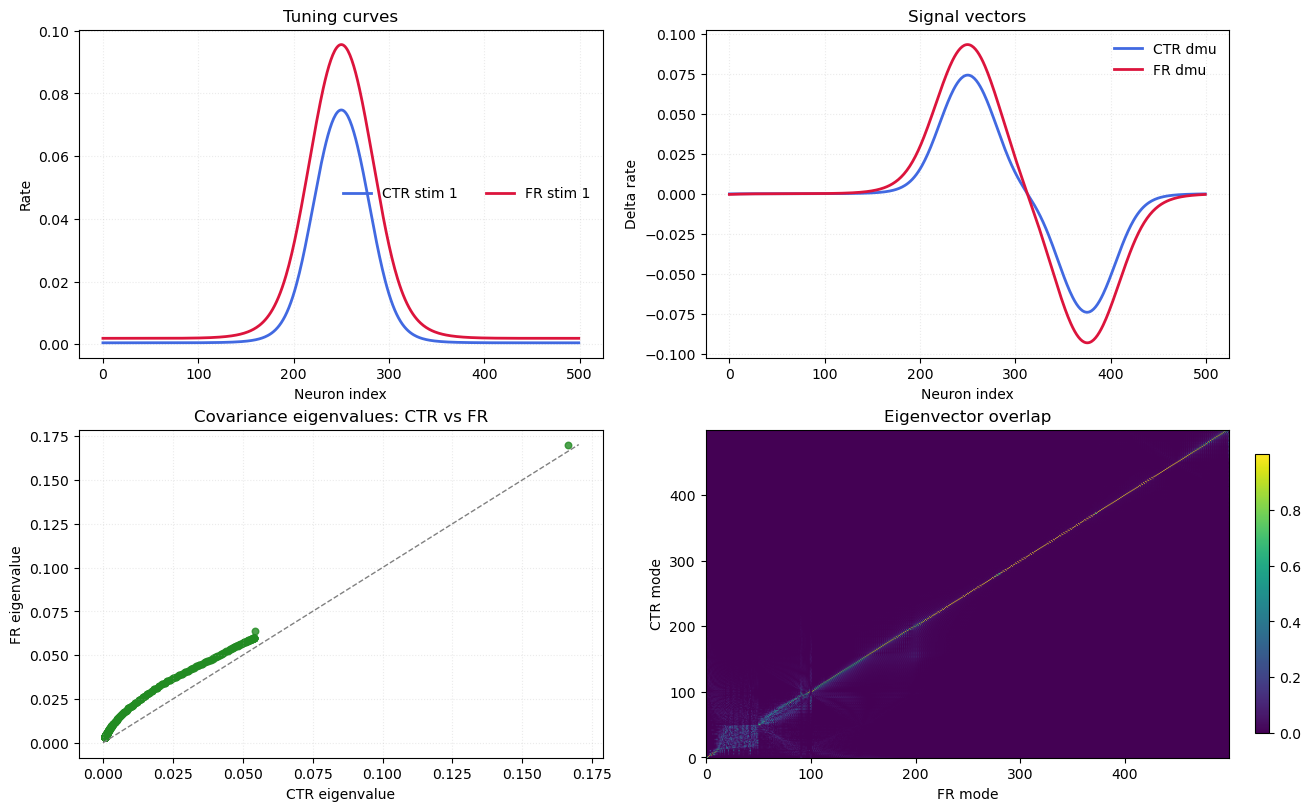

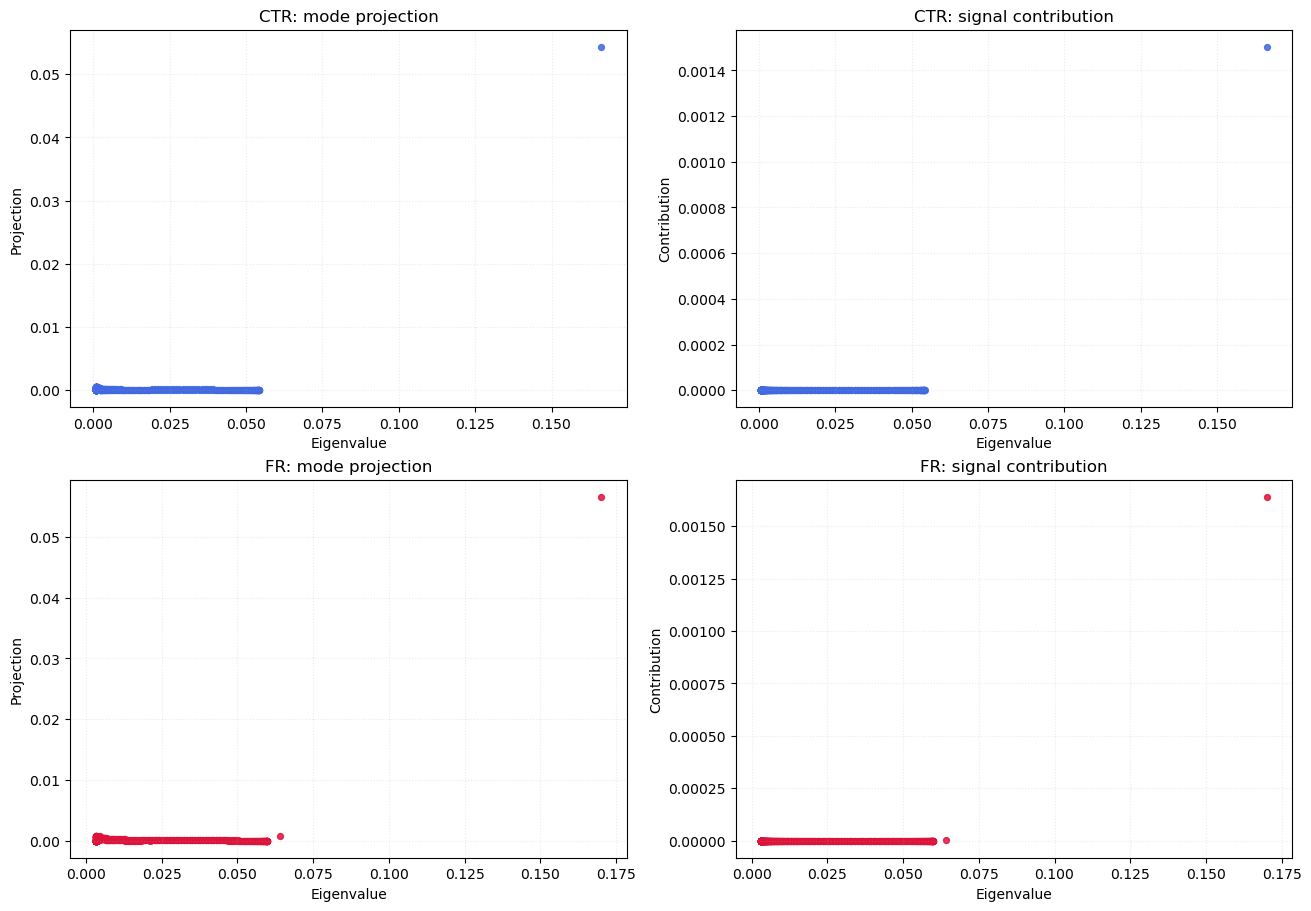

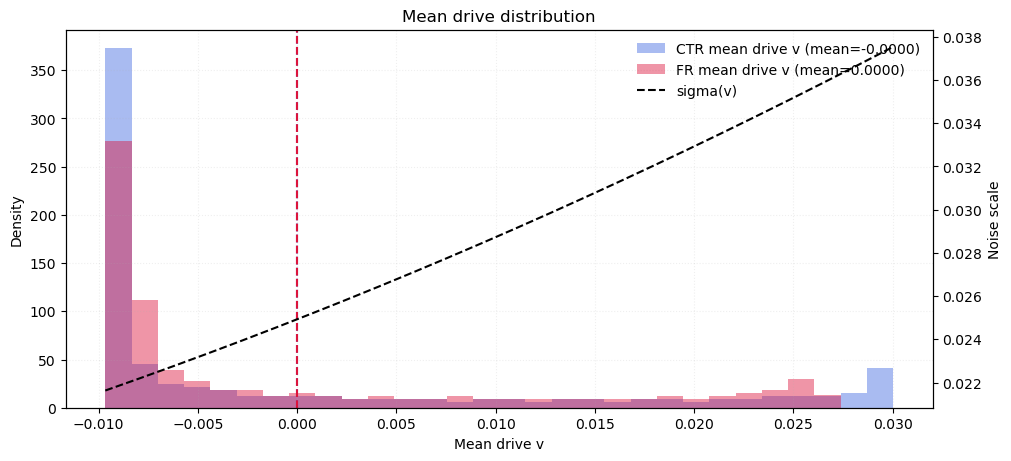

Summary metrics
metric                         CTR          FR
----------------------------------------------
mean rate                   0.0112      0.0176
Energy                      0.0195      0.0177
||dmu||                     0.7444      0.9957
LR estimate                 3.8845      3.2481
PR(dmu)                     140.64      158.88
weak fraction               0.4040      0.4120
trace(sigma)                5.1710      7.6476
lam_max                     0.7626      0.7160
top-10 alignment            0.4971      0.4930
true signal ratio                       0.8362


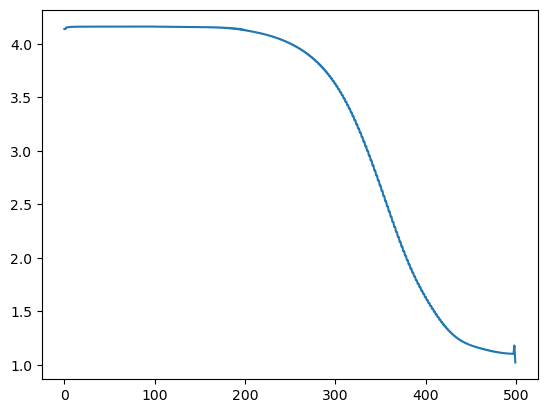

In [15]:
# ------------------------------------------------------------
# Example comparison
# ------------------------------------------------------------


@torch.no_grad()
def compare_static(
    N, J, T, c_ctr, c_fr,
    b, I, eta_std, sigma0, u0, du,db,
    theta_ctr,
    theta_fr,
    width, amp,
    center1, center2,Q,
    device="cpu",
):
    # two stimuli
    x1 = ring_gaussian_bump(N, center=center1, width=width, amp=amp, device=device)
    x2 = ring_gaussian_bump(N, center=center2, width=width, amp=amp, device=device)
    x1 = Q @ x1
    x2 = Q @ x2
    # CTR
    mu1c, uarray_ctr,energy_ctr = solve_mean_field(J, x1, T=T, c=c_ctr,b=b, I = I,eta_std= eta_std, sigma0= sigma0,
                             u0=u0, du=du,db = db, theta=theta_ctr)
    mu2c,_,_ = solve_mean_field(J, x2, T=T, c=c_ctr, b=b, I = I, eta_std= eta_std, sigma0= sigma0,
                             u0=u0, du=du,db = db, theta=theta_ctr)

    # FR
    mu1f, uarray_fr,energy_fr = solve_mean_field(J, x1, T=T, c=c_fr, b=b, I = I, eta_std= eta_std, sigma0= sigma0,
                             u0=u0, du=du,db = db, theta=theta_fr)
    mu2f,_,_ = solve_mean_field(J, x2, T=T, c=c_fr, b=b, I = I, eta_std= eta_std, sigma0= sigma0,
                             u0=u0, du=du,db = db, theta=theta_fr)
    print(f" Mean recurrent activity: {(J@mu1c).mean():.3f}, Input activity: {x1.mean():.3f}")
    print(f" Max recurrent activity: {(J@mu1c).max():.3f}, Input activity: {x1.max():.3f}")
    output_function(mu1c, mu2c, mu1f, mu2f,x1,x2,uarray_ctr,uarray_fr,energy_ctr, energy_fr, W=J, T=T, c_ctr=c_ctr, c_fr=c_fr, sigma0=sigma0, eta_std=eta_std, u0=u0, du=du, b=b, db=db, theta_ctr=theta_ctr, theta_fr=theta_fr)

    return {
        "mu1c": mu1c, "mu2c": mu2c, "dmu_c": mu1c - mu2c,
        "mu1f": mu1f, "mu2f": mu2f, "dmu_f": mu1f - mu2f,
        "x1": x1, "x2": x2,
        "uarray1": uarray_ctr, "uarray2": uarray_fr,
        "energy_ctr": energy_ctr,
        "energy_fr": energy_fr,
        "chi_fr": Chi_from_s(J, gain_from_v(uarray_fr, T=T, c=c_fr, b=b, db=db, eta_std=eta_std, sigma0=sigma0, u0=u0, du=du, theta=theta_fr), c=c_fr),
        "chi_ctr": Chi_from_s(J, gain_from_v(uarray_ctr, T=T, c=c_ctr, b=b, db=db, eta_std=eta_std, sigma0=sigma0, u0=u0, du=du, theta=theta_ctr), c=c_ctr),
    }

# ------------------------------------------------------------
# Example usage
# ------------------------------------------------------------
def main():
    device = "cpu"
    N = 500
    c_ctr = 1.0
    c_fr  = 0.8   
    I = None


    # thr_frac = 0.1
    # T = 0.03
    # b = -0.08
    # width = thr_frac * N //2
    # amp = 0.01

    # db = 0.005
    # eta_std = 0.02
    # sigma0 = 0.0001
    # u0 = 0.00
    # du = 0.01



    thr_frac = 0.2
    T = 0.01
    b = -0.09
    width = thr_frac * N //2
    amp = 0.03
    db = 0.00# 005
    eta_std = 0.04
    sigma0 = 0.001
    u0 = 0.01
    du = 0.05




    g_dis = 0.0 #0.3
    theta_dis = 0.00 # 0.02
    theta_base = make_static_thresholds(N, sigma_theta=theta_dis, device=device, seed=0)
    W =make_ring(N, threshold_active_fraction=thr_frac, g_disorder=g_dis, device=device)
    # A = torch.randn(N, N, device=device)
    # Q, _ = torch.linalg.qr(A)
    # W =  Q @ W @ Q.T
    # W.diagonal().zero_()
    # Q = torch.eye(N)
    # check if W is symmetric and has zero diagonal

    # assert torch.allclose(W, W.T, atol=1e-6), "W is not symmetric"
    # assert torch.allclose(W.diagonal(), torch.zeros(N, device=device), atol=1e-6), "W diagonal is not zero"

    out = compare_static(
        N=N, J=W, T=T,
        c_ctr=c_ctr,
        c_fr=c_fr,b=b, I=I, eta_std=eta_std, sigma0=sigma0, u0=u0, du=du, db=db,
        theta_ctr=theta_base,
        theta_fr=theta_base,
        width=width, amp=amp,
        center1=N//2, center2=(N+250)//2, Q=Q,
        device=device,
    )
    return N,c_ctr,c_fr, thr_frac, width, amp, T, W, b, I, eta_std, sigma0, u0, du, db, theta_base, theta_base, out,Q

N,c_ctr,c_fr, thr_frac, width, amp, T, W, b, I, eta_std, sigma0, u0, du, db, theta_base, theta_base, mf_out,Q = main()

In [21]:
sigma_fr_small = mf_out["chi_fr"]
sigma_ctr_small = mf_out["chi_ctr"]
dx_fr_small = mf_out["x1"] - mf_out["x2"]
dx_ctr_small = mf_out["x1"] - mf_out["x2"]
dmu_fr_small = mf_out["dmu_f"]
dmu_ctr_small = mf_out["dmu_c"]

In [8]:
sigma_fr_large = mf_out["chi_fr"]
sigma_ctr_large = mf_out["chi_ctr"]
dx_fr_large = mf_out["x1"] - mf_out["x2"]
dx_ctr_large = mf_out["x1"] - mf_out["x2"]
dmu_fr_large = mf_out["dmu_f"]
dmu_ctr_large = mf_out["dmu_c"]

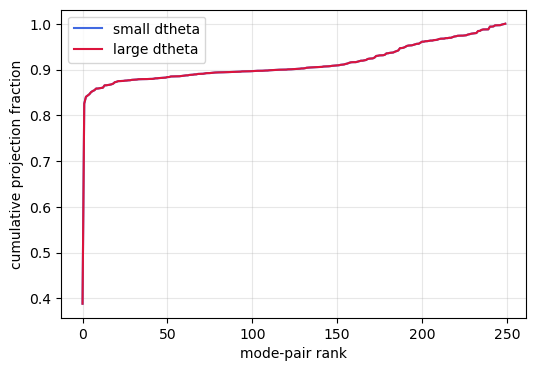

In [9]:
def plot_cumulative_projection(sigma, dx, label, color):
    evals, evecs = torch.linalg.eigh(sigma)
    proj = (evecs.T @ dx).pow(2)

    # sort by descending eigenvalue
    order = torch.argsort(evals, descending=True)
    proj = proj[order]

    # optional: sum neighboring modes in pairs to reduce degeneracy noise
    m = (proj.numel() // 2) * 2
    proj_pair = proj[:m].reshape(-1, 2).sum(dim=1)

    cum = torch.cumsum(proj_pair, dim=0) / proj_pair.sum()
    plt.plot(cum.cpu(), label=label, color=color)

plt.figure(figsize=(6,4))
plot_cumulative_projection(sigma_fr_small, dmu_fr_small, "small dtheta", "royalblue")
plot_cumulative_projection(sigma_fr_large, dmu_fr_large, "large dtheta", "crimson")
plt.xlabel("mode-pair rank")
plt.ylabel("cumulative projection fraction")
plt.legend()
plt.grid(alpha=0.3)


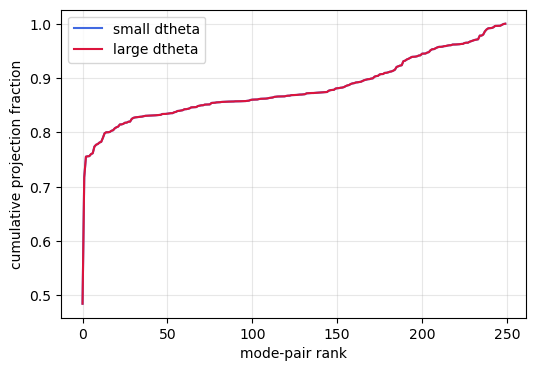

In [10]:
plt.figure(figsize=(6,4))
plot_cumulative_projection(sigma_ctr_small, dmu_ctr_small, "small dtheta", "royalblue")
plot_cumulative_projection(sigma_ctr_large, dmu_ctr_large, "large dtheta", "crimson")
plt.xlabel("mode-pair rank")
plt.ylabel("cumulative projection fraction")
plt.legend()
plt.grid(alpha=0.3)


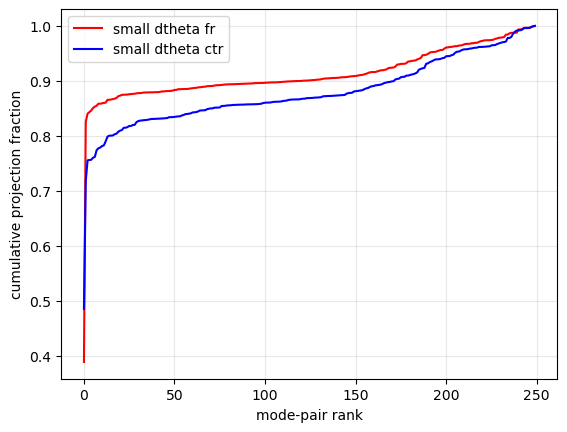

In [11]:
plot_cumulative_projection(sigma_fr_small, dmu_fr_small, "small dtheta fr", "red")
# plot_cumulative_projection(sigma_fr_large, dmu_fr_large, "large dtheta fr", "crimson")
plot_cumulative_projection(sigma_ctr_small, dmu_ctr_small, "small dtheta ctr", "blue")
# plot_cumulative_projection(sigma_ctr_large, dmu_ctr_large, "large dtheta ctr", "royalblue")
plt.xlabel("mode-pair rank")
plt.ylabel("cumulative projection fraction")
plt.legend()
plt.grid(alpha=0.3)


# Experimental Like Tuning Curve and Dmu vs Theta

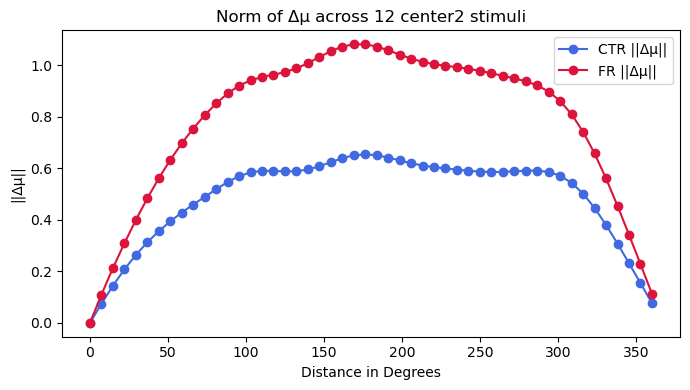

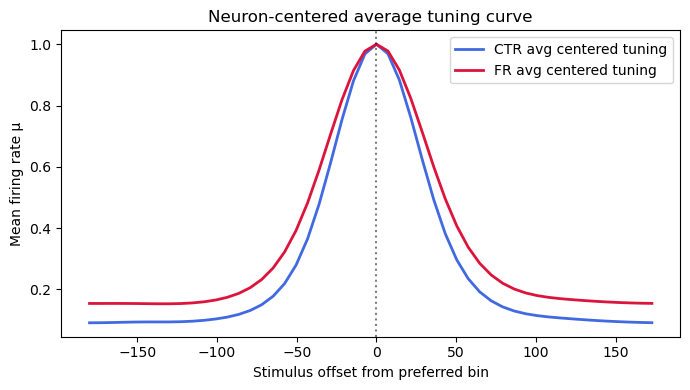

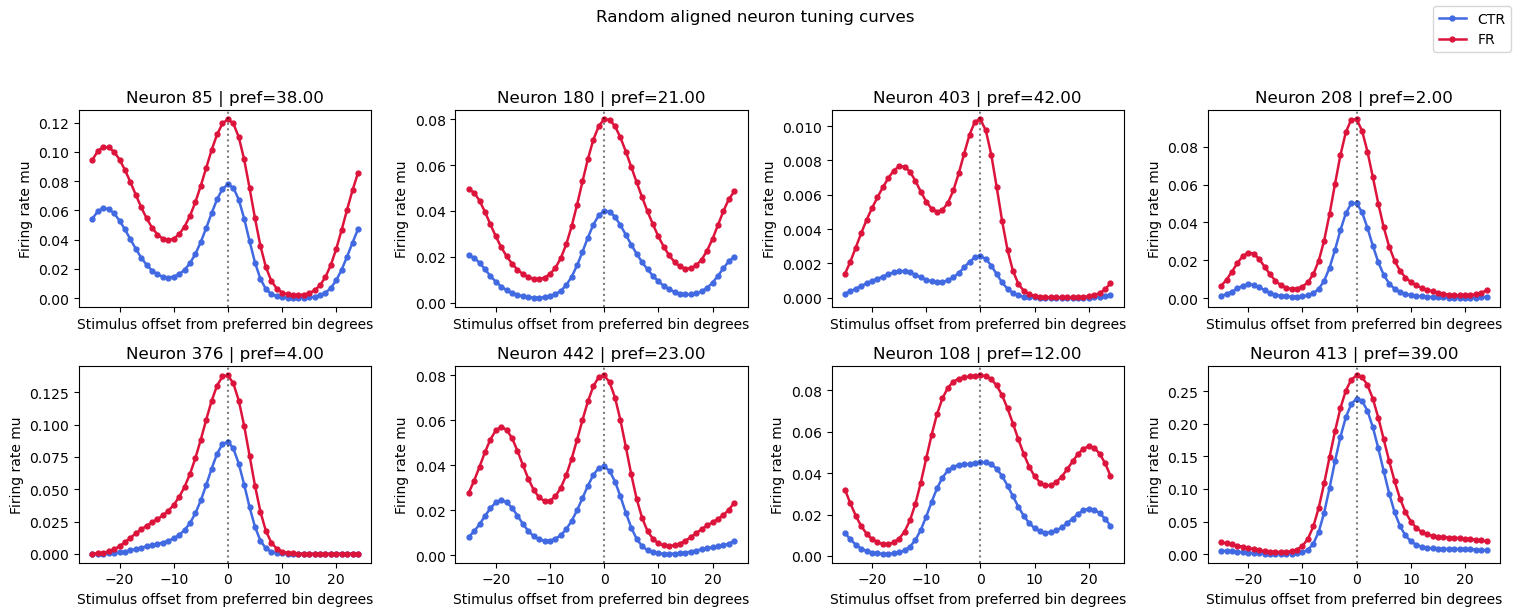

In [46]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def subbin_peak_index(curve):
    peak = int(torch.argmax(curve).item())
    left = curve[(peak - 1) % curve.numel()]
    center = curve[peak]
    right = curve[(peak + 1) % curve.numel()]
    denom = left - 2 * center + right

    if torch.abs(denom) < 1e-12:
        return float(peak)

    delta = 0.5 * (left - right) / denom
    delta = torch.clamp(delta, -0.5, 0.5)
    return float(peak) + float(delta.item())

def fractional_roll_1d(curve, shift):
    k = curve.numel()
    freqs = torch.fft.fftfreq(k, d=1.0, device=curve.device)
    phase = torch.exp(-2j * np.pi * freqs * shift)
    shifted = torch.fft.ifft(torch.fft.fft(curve) * phase).real
    return shifted.to(curve.dtype)

def subbin_peak_index_nonperiodic(curve):
    peak = int(torch.argmax(curve).item())
    if peak == 0 or peak == curve.numel() - 1:
        return float(peak)
    left = curve[peak - 1]
    center = curve[peak]
    right = curve[peak + 1]
    denom = left - 2 * center + right
    if torch.abs(denom) < 1e-12:
        return float(peak)
    delta = 0.5 * (left - right) / denom
    return float(peak) + float(torch.clamp(delta, -0.5, 0.5).item())


@torch.no_grad()
def compare_static_hetero_multi_center2(
    N, J, T, c_ctr, c_fr,
    b, I, eta_std, sigma0, u0, du,db,
    theta_ctr,
    theta_fr,
    width, amp,Q,
    center1,
    n_center2=12,
    center2_list=None,
    device="cpu",
    plot_random_examples=True,
    n_random_examples=8,
    random_seed=None,
    example_ncols=4,
):
    # 12 test stimuli for center2 (uniformly around ring, relative to center1)
    if center2_list is None:
        offsets = np.linspace(0, N, n_center2, endpoint=False)
        center2_list = ((center1 + offsets) % N).tolist()
    K = len(center2_list)

    # Stimulus 1 (fixed)
    b1 = ring_gaussian_bump(N, center=center1, width=width, amp=amp, device=device)
    b1 = Q @ b1 
    # Solve stim1 once per condition
    mu1c,_,_= solve_mean_field(J, b1, T=T, c=c_ctr, b=b, I=I, eta_std=eta_std, sigma0=sigma0, u0=u0, du=du,db=db, theta=theta_ctr)
    mu1f,_,_ = solve_mean_field(J, b1, T=T, c=c_fr, b=b, I=I, eta_std=eta_std, sigma0=sigma0, u0=u0, du=du,db=db, theta=theta_fr)

    dmu_norms_ctr = []
    dmu_norms_fr = []

    # tuning_curves_* shape: (K stimuli, N neurons)
    tuning_curves_ctr = []
    tuning_curves_fr = []

    for c2 in center2_list:

        b2 = ring_gaussian_bump(N, center=float(c2), width=width, amp=amp, device=device)
        b2 = Q @ b2
        mu2c,_,_ = solve_mean_field(J, b2, T=T, c=c_ctr, b=b, I=I, eta_std=eta_std, sigma0=sigma0, u0=u0, du=du,db=db, theta=theta_ctr)
        mu2f,_,_ = solve_mean_field(J, b2, T=T, c=c_fr, b=b, I=I, eta_std=eta_std, sigma0=sigma0, u0=u0, du=du,db=db, theta=theta_fr)

        dmu_c = mu1c - mu2c
        dmu_f = mu1f - mu2f

        dmu_norms_ctr.append(dmu_c.norm().item())
        dmu_norms_fr.append(dmu_f.norm().item())

        tuning_curves_ctr.append(mu2c)
        tuning_curves_fr.append(mu2f)

    tuning_curves_ctr = torch.stack(tuning_curves_ctr, dim=0)  # (K, N)
    tuning_curves_fr = torch.stack(tuning_curves_fr, dim=0)    # (K, N)

    # Align each neuron's tuning curve by a sub-bin estimate of its CTR preferred stimulus
    pref_idx_ctr = torch.argmax(tuning_curves_ctr, dim=0)
    center_bin = K // 2

    aligned_ctr = torch.empty_like(tuning_curves_ctr)
    aligned_fr = torch.empty_like(tuning_curves_fr)

    for i in range(N):
        shift = center_bin - int(pref_idx_ctr[i].item())
        aligned_ctr[:, i] = torch.roll(tuning_curves_ctr[:, i], shifts=shift, dims=0)
        aligned_fr[:, i] = torch.roll(tuning_curves_fr[:, i], shifts=shift, dims=0)

    avg_tuning_ctr = torch.nanmean(aligned_ctr, dim=1)
    avg_tuning_fr = torch.nanmean(aligned_fr, dim=1)

    valid_mask = torch.isfinite(aligned_ctr).all(dim=0) & torch.isfinite(aligned_fr).all(dim=0)
    valid_indices = torch.nonzero(valid_mask, as_tuple=False).flatten().cpu().numpy()
    sample_count = max(0, min(int(n_random_examples), len(valid_indices)))
    random_example_indices = np.array([], dtype=int)
    if plot_random_examples and sample_count > 0:
        rng = np.random.default_rng(random_seed)
        random_example_indices = rng.choice(valid_indices, size=sample_count, replace=False)

    # x-axis in "stimulus-bin offset from preferred"
    x = np.arange(K) - center_bin

    # Plot 1: ||Δμ|| over center2 + mean
    distance = N
    number = K
    plt.figure(figsize=(7, 4))
    plt.plot(np.linspace(0,distance,number)*360/N, dmu_norms_ctr[:number], "o-", color="royalblue", label="CTR ||Δμ||")
    plt.plot(np.linspace(0,distance,number)*360/N, dmu_norms_fr[:number], "o-", color="crimson", label="FR ||Δμ||")
    plt.xlabel("Distance in Degrees")
    plt.ylabel("||Δμ||")
    plt.title("Norm of Δμ across 12 center2 stimuli")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot 2: Average centered tuning curves
    x_values = x * (360.0 / K)  # Convert bin offsets to degrees
    plt.figure(figsize=(7, 4))
    plt.plot(x_values, avg_tuning_ctr.cpu()/avg_tuning_ctr.cpu().max(), color="royalblue", lw=2, label="CTR avg centered tuning")
    plt.plot(x_values, avg_tuning_fr.cpu()/avg_tuning_fr.cpu().max(), color="crimson", lw=2, label="FR avg centered tuning")
    plt.axvline(0, color="k", ls=":", alpha=0.5)
    plt.xlabel("Stimulus offset from preferred bin")
    plt.ylabel("Mean firing rate μ")
    plt.title("Neuron-centered average tuning curve")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot 3: Random aligned neuron examples in raw mu units
    if plot_random_examples and sample_count > 0:
        ncols = max(1, int(example_ncols))
        nrows = int(np.ceil(sample_count / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(3.8 * ncols, 3.0 * nrows), squeeze=False, sharex=True)
        axes = axes.ravel()

        for ax, neuron_idx in zip(axes, random_example_indices):
            idx = int(neuron_idx)
            ax.plot(x, aligned_ctr[:, idx].cpu().numpy(), "o-", color="royalblue", lw=1.8, ms=3.5, label="CTR")
            ax.plot(x, aligned_fr[:, idx].cpu().numpy(), "o-", color="crimson", lw=1.8, ms=3.5, label="FR")
            ax.axvline(0, color="k", ls=":", alpha=0.5)
            ax.set_title(f"Neuron {idx} | pref={pref_idx_ctr[idx].item():.2f}")
            ax.set_xlabel("Stimulus offset from preferred bin degrees")
            ax.set_ylabel("Firing rate mu")

        for ax in axes[sample_count:]:
            ax.axis("off")

        handles, labels = axes[0].get_legend_handles_labels()
        if handles:
            fig.legend(handles, labels, loc="upper right")
        fig.suptitle("Random aligned neuron tuning curves", y=1.02)
        fig.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    return {
        "center2_list": center2_list,
        "dmu_norms_ctr": dmu_norms_ctr,
        "dmu_norms_fr": dmu_norms_fr,
        "avg_norm_ctr": float(np.mean(dmu_norms_ctr)),
        "avg_norm_fr": float(np.mean(dmu_norms_fr)),
        "avg_tuning_ctr": avg_tuning_ctr,
        "avg_tuning_fr": avg_tuning_fr,
        "aligned_ctr": aligned_ctr,
        "aligned_fr": aligned_fr,
        "pref_idx_ctr": pref_idx_ctr,
        "random_example_indices": random_example_indices.tolist(),
        "n_random_examples": int(n_random_examples),
        "random_seed": random_seed,
    }


# --- Run it with your current parameters ---
out_multi = compare_static_hetero_multi_center2(
    N=N, J=W, T=T,
    c_ctr=c_ctr,
    c_fr=c_fr,
    b=b, I=I, eta_std=eta_std, sigma0=sigma0, u0=u0, du=du,db=db,
    theta_ctr=theta_base, theta_fr=theta_base,
    width=width, amp=amp,Q=Q,
    center1=N//2,
    n_center2=50,
    device="cpu",
)


# I/O Curve

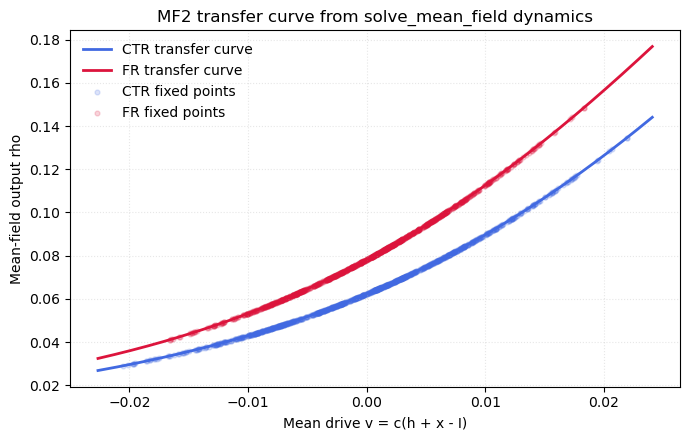

CTR half-activation mean drive v: 0.0241
FR half-activation mean drive v:  0.0241
CTR fixed-point max |rho - F(v)|: 4.470e-08
FR fixed-point max |rho - F(v)|:  4.470e-08
CTR uses vector theta: plotted line is the population-average curve across theta.
FR uses vector theta: plotted line is the population-average curve across theta.


In [150]:
@torch.no_grad()
def mean_field_transfer_curve(
    v_grid,
    *,
    T,
    b,
    c,
    eta_std,
    sigma0,
    u0,
    du,
    db=0.01,
    theta=None,
    gh_points=32,
    device="cpu",
):
    v_grid = torch.as_tensor(v_grid, device=device, dtype=torch.float64)
    theta_tensor = None if theta is None else torch.as_tensor(theta, device=device, dtype=torch.float64)

    if theta_tensor is not None and theta_tensor.ndim > 0 and theta_tensor.numel() > 1:
        transfer = mean_field_transfer_from_v(
            v_grid[:, None],
            T=T,
            c=c,
            b=b,
            db=db,
            eta_std=eta_std,
            sigma0=sigma0,
            u0=u0,
            du=du,
            theta=theta_tensor,
            gh_points=gh_points,
            device=device,
            dtype=torch.float64,
        )
        rho_curve = transfer["rho"].mean(dim=1)
        u_curve = transfer["u"].mean(dim=1)
        sigma_curve = transfer["sigma_u"][:, 0]
    else:
        transfer = mean_field_transfer_from_v(
            v_grid,
            T=T,
            c=c,
            b=b,
            db=db,
            eta_std=eta_std,
            sigma0=sigma0,
            u0=u0,
            du=du,
            theta=theta_tensor,
            gh_points=gh_points,
            device=device,
            dtype=torch.float64,
        )
        rho_curve = transfer["rho"]
        u_curve = transfer["u"]
        sigma_curve = transfer["sigma_u"]

    b_eff = transfer["b_eff"]
    if isinstance(b_eff, torch.Tensor):
        b_eff = float(b_eff.detach().cpu().mean().item())
    else:
        b_eff = float(b_eff)

    return {
        "v": v_grid.detach().cpu().numpy(),
        "rho": rho_curve.detach().cpu().numpy(),
        "u": u_curve.detach().cpu().numpy(),
        "sigma_u": sigma_curve.detach().cpu().numpy(),
        "r": transfer["r"],
        "b_eff": b_eff,
    }


def _theta_is_scalar(theta):
    if theta is None:
        return True
    if isinstance(theta, torch.Tensor):
        return theta.ndim == 0 or theta.numel() == 1
    return np.ndim(theta) == 0


def _curve_overlay_error(curve, v_points, rho_points):
    interp = np.interp(v_points, curve["v"], curve["rho"])
    return float(np.max(np.abs(rho_points - interp)))


ctr_op1 = mean_field_operating_point(
    W, mf_out["mu1c"], mf_out["x1"],
    c=c_ctr, T=T, b=b, I=I, eta_std=eta_std, sigma0=sigma0,
    u0=u0, du=du, db=db, theta=theta_base,
)
ctr_op2 = mean_field_operating_point(
    W, mf_out["mu2c"], mf_out["x2"],
    c=c_ctr, T=T, b=b, I=I, eta_std=eta_std, sigma0=sigma0,
    u0=u0, du=du, db=db, theta=theta_base,
)
fr_op1 = mean_field_operating_point(
    W, mf_out["mu1f"], mf_out["x1"],
    c=c_fr, T=T, b=b, I=I, eta_std=eta_std, sigma0=sigma0,
    u0=u0, du=du, db=db, theta=theta_base,
)
fr_op2 = mean_field_operating_point(
    W, mf_out["mu2f"], mf_out["x2"],
    c=c_fr, T=T, b=b, I=I, eta_std=eta_std, sigma0=sigma0,
    u0=u0, du=du, db=db, theta=theta_base,
)

all_v = torch.cat([
    ctr_op1["v"].reshape(-1),
    ctr_op2["v"].reshape(-1),
    fr_op1["v"].reshape(-1),
    fr_op2["v"].reshape(-1),
])
v_min = float(all_v.min().item())
v_max = float(all_v.max().item())
v_pad = max(0.05 * (v_max - v_min), 1e-3)
drive_grid = torch.linspace(v_min - v_pad, v_max + v_pad, 400, device=W.device, dtype=W.dtype)

ctr_curve = mean_field_transfer_curve(
    drive_grid,
    T=T,
    b=b,
    c=c_ctr,
    eta_std=eta_std,
    sigma0=sigma0,
    u0=u0,
    du=du,
    db=db,
    theta=theta_base,
    gh_points=32,
    device=W.device,
)
fr_curve = mean_field_transfer_curve(
    drive_grid,
    T=T,
    b=b,
    c=c_fr,
    eta_std=eta_std,
    sigma0=sigma0,
    u0=u0,
    du=du,
    db=db,
    theta=theta_base,
    gh_points=32,
    device=W.device,
)

ctr_fixed_v = np.concatenate([
    ctr_op1["v"].detach().cpu().numpy(),
    ctr_op2["v"].detach().cpu().numpy(),
])
ctr_fixed_rho = np.concatenate([
    mf_out["mu1c"].detach().cpu().numpy(),
    mf_out["mu2c"].detach().cpu().numpy(),
])
fr_fixed_v = np.concatenate([
    fr_op1["v"].detach().cpu().numpy(),
    fr_op2["v"].detach().cpu().numpy(),
])
fr_fixed_rho = np.concatenate([
    mf_out["mu1f"].detach().cpu().numpy(),
    mf_out["mu2f"].detach().cpu().numpy(),
])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(ctr_curve["v"], ctr_curve["rho"], color="royalblue", lw=2, label="CTR transfer curve")
ax.plot(fr_curve["v"], fr_curve["rho"], color="crimson", lw=2, label="FR transfer curve")
ax.scatter(ctr_fixed_v, ctr_fixed_rho, color="royalblue", s=12, alpha=0.18, label="CTR fixed points")
ax.scatter(fr_fixed_v, fr_fixed_rho, color="crimson", s=12, alpha=0.18, label="FR fixed points")
ax.set_xlabel("Mean drive v = c(h + x - I)")
ax.set_ylabel("Mean-field output rho")
ax.set_title("MF2 transfer curve from solve_mean_field dynamics")
ax.grid(alpha=0.3, linestyle=":")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

ctr_half_idx = np.argmin(np.abs(ctr_curve["rho"] - 0.5))
fr_half_idx = np.argmin(np.abs(fr_curve["rho"] - 0.5))
print(f"CTR half-activation mean drive v: {ctr_curve['v'][ctr_half_idx]:.4f}")
print(f"FR half-activation mean drive v:  {fr_curve['v'][fr_half_idx]:.4f}")

ctr_transfer_resid = max(
    float(torch.max(torch.abs(mf_out["mu1c"] - ctr_op1["rho_transfer"])).item()),
    float(torch.max(torch.abs(mf_out["mu2c"] - ctr_op2["rho_transfer"])).item()),
)
fr_transfer_resid = max(
    float(torch.max(torch.abs(mf_out["mu1f"] - fr_op1["rho_transfer"])).item()),
    float(torch.max(torch.abs(mf_out["mu2f"] - fr_op2["rho_transfer"])).item()),
)
print(f"CTR fixed-point max |rho - F(v)|: {ctr_transfer_resid:.3e}")
print(f"FR fixed-point max |rho - F(v)|:  {fr_transfer_resid:.3e}")

if _theta_is_scalar(theta_base):
    ctr_overlay_err = max(
        _curve_overlay_error(ctr_curve, ctr_op1["v"].detach().cpu().numpy(), mf_out["mu1c"].detach().cpu().numpy()),
        _curve_overlay_error(ctr_curve, ctr_op2["v"].detach().cpu().numpy(), mf_out["mu2c"].detach().cpu().numpy()),
    )
    print(f"CTR curve overlay max |rho - curve(v)|: {ctr_overlay_err:.3e}")
else:
    print("CTR uses vector theta: plotted line is the population-average curve across theta.")

if _theta_is_scalar(theta_base):
    fr_overlay_err = max(
        _curve_overlay_error(fr_curve, fr_op1["v"].detach().cpu().numpy(), mf_out["mu1f"].detach().cpu().numpy()),
        _curve_overlay_error(fr_curve, fr_op2["v"].detach().cpu().numpy(), mf_out["mu2f"].detach().cpu().numpy()),
    )
    print(f"FR curve overlay max |rho - curve(v)|:  {fr_overlay_err:.3e}")
else:
    print("FR uses vector theta: plotted line is the population-average curve across theta.")


# Clark Evectors

=== Diagnostics ===
N=500, threshold_active_fraction=0.1, seed=0, device=cpu
||Q^T Q - I||_F               = 1.424e-05
||K - K^T||_F                 = 0.000e+00
||K_rot - K_rot^T||_F         = 1.206e-07
max |lambda(K) - lambda(K_rot)| = 4.470e-08
reconstruction err K          = 4.225e-07
reconstruction err K_rot      = 4.268e-07
max unit-norm err eigvec(K)   = 7.153e-07
max unit-norm err eigvec(K_rot)= 8.345e-07


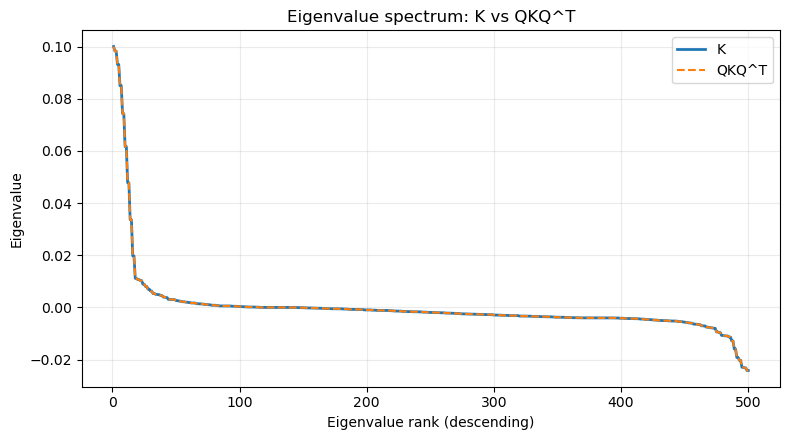

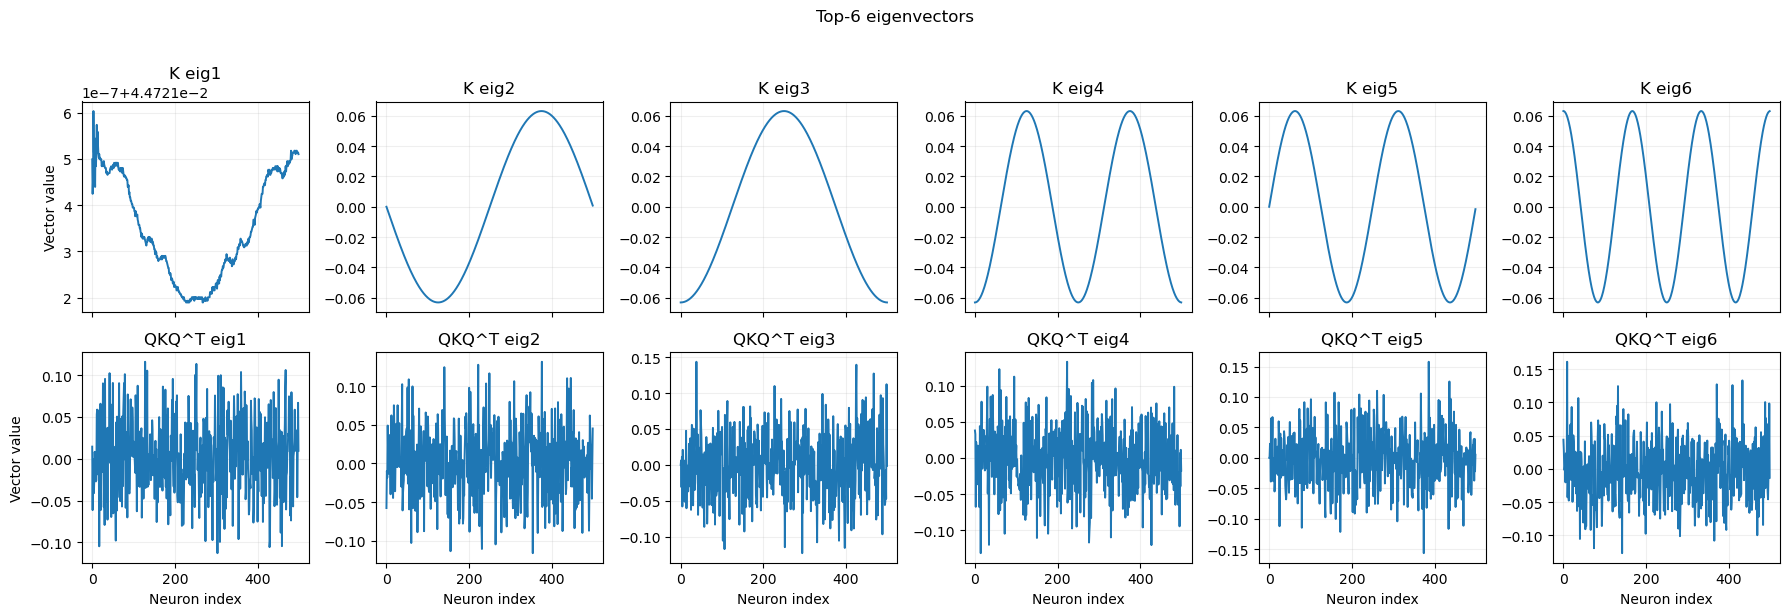

In [151]:
def eigh_desc(M: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    """Symmetric eigendecomposition sorted by descending eigenvalue."""
    evals, evecs = torch.linalg.eigh(M)
    idx = torch.argsort(evals, descending=True)
    return evals[idx], evecs[:, idx]


def canonicalize_signs(V: torch.Tensor) -> torch.Tensor:
    """
    Resolve sign ambiguity by making each eigenvector's max-abs entry positive.
    """
    Vc = V.clone()
    n, k = Vc.shape
    max_idx = torch.argmax(torch.abs(Vc), dim=0)
    cols = torch.arange(k, device=Vc.device)
    signs = torch.sign(Vc[max_idx, cols])
    signs = torch.where(signs == 0, torch.ones_like(signs), signs)
    Vc = Vc * signs
    return Vc


@torch.no_grad()
def plot_k_eigenvectors(
    N: int,
    threshold_active_fraction: float,
    device="cpu",
    seed: int = 0,
    top_k: int = 6,
    atol: float = 1e-6,
):
    """
    Plot eigensystems for K and K_rot = Q K Q^T.
    - Figure A: eigenvalue spectra overlay
    - Figure B: top-k eigenvectors, row1=K, row2=K_rot
    Also prints diagnostics:
      ||Q^TQ - I||_F, symmetry errors, max eig difference, reconstruction errors.
    """
    # Build matrices
    K = make_ring(N=N, threshold_active_fraction=threshold_active_fraction,g_disorder = 0.0, device=device)
    A = torch.randn(N, N, device=device, dtype=K.dtype)
    Q, _ = torch.linalg.qr(A)
    K_rot = Q @ K @ Q.T

    # Structural checks
    if K.ndim != 2 or K.shape[0] != K.shape[1]:
        raise ValueError(f"K must be square; got {tuple(K.shape)}")
    if K_rot.ndim != 2 or K_rot.shape[0] != K_rot.shape[1]:
        raise ValueError(f"K_rot must be square; got {tuple(K_rot.shape)}")
    if not torch.isfinite(K).all() or not torch.isfinite(K_rot).all() or not torch.isfinite(Q).all():
        raise ValueError("Non-finite values found in Q/K/K_rot")

    n = K.shape[0]
    top_k = int(max(1, min(top_k, n)))

    # Diagnostics helpers
    def fro(x: torch.Tensor) -> float:
        return float(torch.linalg.norm(x, ord='fro').item())

    I = torch.eye(n, device=K.device, dtype=K.dtype)
    orth_err = fro(Q.T @ Q - I)
    sym_err_k = fro(K - K.T)
    sym_err_kr = fro(K_rot - K_rot.T)

    # Eigensystems
    lam_k, U_k = eigh_desc(K)
    lam_kr, U_kr = eigh_desc(K_rot)
    U_k = canonicalize_signs(U_k)
    U_kr = canonicalize_signs(U_kr)

    # Spectral checks
    eig_max_diff = float(torch.max(torch.abs(lam_k - lam_kr)).item())

    # Reconstruction checks
    K_rec = U_k @ torch.diag(lam_k) @ U_k.T
    K_rot_rec = U_kr @ torch.diag(lam_kr) @ U_kr.T
    rec_err_k = fro(K - K_rec)
    rec_err_kr = fro(K_rot - K_rot_rec)

    # Unit-norm checks for eigenvectors
    unit_norm_err_k = float(torch.max(torch.abs(torch.linalg.norm(U_k, dim=0) - 1.0)).item())
    unit_norm_err_kr = float(torch.max(torch.abs(torch.linalg.norm(U_kr, dim=0) - 1.0)).item())

    # Print diagnostics
    print("=== Diagnostics ===")
    print(f"N={n}, threshold_active_fraction={threshold_active_fraction}, seed={seed}, device={device}")
    print(f"||Q^T Q - I||_F               = {orth_err:.3e}")
    print(f"||K - K^T||_F                 = {sym_err_k:.3e}")
    print(f"||K_rot - K_rot^T||_F         = {sym_err_kr:.3e}")
    print(f"max |lambda(K) - lambda(K_rot)| = {eig_max_diff:.3e}")
    print(f"reconstruction err K          = {rec_err_k:.3e}")
    print(f"reconstruction err K_rot      = {rec_err_kr:.3e}")
    print(f"max unit-norm err eigvec(K)   = {unit_norm_err_k:.3e}")
    print(f"max unit-norm err eigvec(K_rot)= {unit_norm_err_kr:.3e}")

    if orth_err > 1e-3:
        print("[WARN] Q orthogonality error is larger than expected.")
    if sym_err_k > atol or sym_err_kr > 1e-3:
        print("[WARN] Symmetry error exceeds tolerance.")
    if eig_max_diff > 1e-4:
        print("[WARN] Eigenvalue mismatch is larger than expected.")

    # Figure A: eigenvalue spectrum overlay
    x_rank = torch.arange(1, n + 1, device=K.device).cpu().numpy()
    lam_k_np = lam_k.detach().cpu().numpy()
    lam_kr_np = lam_kr.detach().cpu().numpy()

    plt.figure(figsize=(8, 4.5))
    plt.plot(x_rank, lam_k_np, lw=2.0, label='K')
    plt.plot(x_rank, lam_kr_np, lw=1.5, ls='--', label='QKQ^T')
    plt.xlabel('Eigenvalue rank (descending)')
    plt.ylabel('Eigenvalue')
    plt.title('Eigenvalue spectrum: K vs QKQ^T')
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Figure B: top-k eigenvectors in 2 x k grid
    fig, axes = plt.subplots(2, top_k, figsize=(3.0 * top_k, 6), sharex=True)
    if top_k == 1:
        # Normalize axes shape to [2, k]
        axes = axes.reshape(2, 1)

    U_k_np = U_k.detach().cpu().numpy()
    U_kr_np = U_kr.detach().cpu().numpy()

    xx = torch.arange(n, device=K.device).cpu().numpy()
    for j in range(top_k):
        ax1 = axes[0, j]
        ax2 = axes[1, j]

        ax1.plot(xx, U_k_np[:, j], lw=1.4)
        ax1.set_title(f'K eig{j+1}')
        ax1.grid(True, alpha=0.20)

        ax2.plot(xx, U_kr_np[:, j], lw=1.4)
        ax2.set_title(f'QKQ^T eig{j+1}')
        ax2.grid(True, alpha=0.20)

    axes[0, 0].set_ylabel('Vector value')
    axes[1, 0].set_ylabel('Vector value')
    for j in range(top_k):
        axes[1, j].set_xlabel('Neuron index')

    fig.suptitle(f'Top-{top_k} eigenvectors', y=1.02)
    plt.tight_layout()
    plt.show()

    return {
        'K': K,
        'Q': Q,
        'K_rot': K_rot,
        'lam_k': lam_k,
        'U_k': U_k,
        'lam_k_rot': lam_kr,
        'U_k_rot': U_kr,
        'diagnostics': {
            'orth_err_fro': orth_err,
            'sym_err_k_fro': sym_err_k,
            'sym_err_krot_fro': sym_err_kr,
            'eig_max_diff': eig_max_diff,
            'recon_err_k_fro': rec_err_k,
            'recon_err_krot_fro': rec_err_kr,
            'unit_norm_err_k': unit_norm_err_k,
            'unit_norm_err_krot': unit_norm_err_kr,
        },
    }

N = 500
threshold_active_fraction = 0.1
device = "cpu"
# Example invocation (assumes N, threshold_active_fraction, and device already defined)
_ = plot_k_eigenvectors(
    N=N,
    threshold_active_fraction=threshold_active_fraction,
    device=device,
    seed=0,
    top_k=6,
)



# SNR Plots

In [29]:
@torch.no_grad()
def mean_variance_factor_correlated_trials(L: int, tau_trials: float, device="cpu") -> float:
    """
    fac(L,tau) = 1 + 2 sum_{k=1}^{L-1} (1-k/L) exp(-k/tau)
    Var(mean) = (Var_per_trial / L) * fac
    """
    if L <= 1:
        return 1.0
    if tau_trials <= 0:
        return 1.0
    ks = torch.arange(1, L, device=device, dtype=torch.float32)
    rho = torch.exp(-ks / float(tau_trials))
    weights = 1.0 - ks / float(L)
    fac = 1.0 + 2.0 * torch.sum(weights * rho)
    return float(fac.item())

@torch.no_grad()
def compare_ctr_fr_quadratic_L_sharedbasis(
    N, J, T, c_ctr, c_fr,
    b, I, eta_std, sigma0, u0, du,db,
    theta_ctr,
    theta_fr,
    width, amp,
    center1, center2,Q,
    sig_theta, L, tau_theta_trials,
    device="cpu",
    ):
    # two stimuli
    x1 = ring_gaussian_bump(N, center=center1, width=width, amp=amp, device=device)
    x2 = ring_gaussian_bump(N, center=center2, width=width, amp=amp, device=device)
    x1 = Q @ x1
    x2 = Q @ x2
    dx = x1-x2
    # CTR
    mu1c, uarray_ctr,energy_ctr = solve_mean_field(J, x1, T=T, c=c_ctr,b=b, I = I,eta_std= eta_std, sigma0= sigma0,
                             u0=u0, du=du,db = db, theta=theta_ctr)
    # mu2c,_,_ = solve_mean_field(J, x2, T=T, c=c_ctr, b=b, I = I, eta_std= eta_std, sigma0= sigma0,
    #                          u0=u0, du=du,db = db, theta=theta_ctr)

    # FR
    mu1f, uarray_fr,energy_fr = solve_mean_field(J, x1, T=T, c=c_fr, b=b, I = I, eta_std= eta_std, sigma0= sigma0,
                             u0=u0, du=du,db = db, theta=theta_fr)
    # mu2f,_,_ = solve_mean_field(J, x2, T=T, c=c_fr, b=b, I = I, eta_std= eta_std, sigma0= sigma0,
    #                          u0=u0, du=du,db = db, theta=theta_fr)
 
    g_ctr = gain_from_v(uarray_ctr, T=T, c=c_ctr, b=b, db=db,
                    eta_std=eta_std, sigma0=sigma0, u0=u0, du=du, theta=theta_ctr)
    g_fr = gain_from_v(uarray_fr, T=T, c=c_fr, b=b, db=db,
                    eta_std=eta_std, sigma0=sigma0, u0=u0, du=du, theta=theta_fr)
    
    Chi_ctr = Chi_from_s(J,g_ctr , c=c_ctr)
    Chi_fr = Chi_from_s(J,g_fr , c=c_fr)
    eval_chi_ctr, _ = torch.linalg.eigh(Chi_ctr)
    eval_chi_fr, _ = torch.linalg.eigh(Chi_fr)

    # linear-response "unit test" dmu
    dmu_c = (c_ctr) * (Chi_ctr @ dx)
    dmu_f = (c_fr) * (Chi_fr  @ dx)

    # trial-mean covariances
    fac = mean_variance_factor_correlated_trials(L, tau_theta_trials, device=device)
    cov_total_fr= (fac / float(L)) * (c_fr * sig_theta) ** 2 * (Chi_fr @ Chi_fr.T)+ T*Chi_fr / float(L)
    cov_total_ctr= (fac / float(L)) * (c_ctr * sig_theta) ** 2 * (Chi_ctr @ Chi_ctr.T)+ T*Chi_ctr / float(L)

    # ---- SNR per mode ---#
    eval_c, evec_c = torch.linalg.eigh(cov_total_ctr) 
    eval_f, evec_f = torch.linalg.eigh(cov_total_fr)
    snr_ctr =torch.full((N,), float('nan'), device=device)
    snr_fr = torch.full((N,), float('nan'), device=device)
    overlap_c = torch.full((N,), float('nan'), device=device)
    overlap_f = torch.full((N,), float('nan'), device=device)

    for i in range(N):
        v_c= evec_c[:, i:i+1]
        overlap_c[i] = (dmu_c @ v_c).item() ** 2 
        # overlap_c[i] = (eval_chi_ctr[i]*c_ctr*dx.norm())**2

        snr_ctr[i] = overlap_c[i] / eval_c[i].item()

        v_f = evec_f[:, i:i+1]
        overlap_f[i] = (dmu_f @ v_f).item() ** 2
        # overlap_f[i] = (eval_chi_fr[i]*c_fr*dx.norm())**2
        snr_fr[i] = overlap_f[i] / eval_f[i].item()
    
    snr_fr = snr_fr.flip(0)  # reverse to match the order of evals (descending)
    snr_ctr = snr_ctr.flip(0)
    eval_f = eval_f.flip(0)
    eval_c = eval_c.flip(0)
    overlap_c = overlap_c.flip(0)
    overlap_f = overlap_f.flip(0)


    return snr_fr, snr_ctr, eval_f, eval_c, overlap_c, overlap_f, eval_chi_fr, eval_chi_ctr


Ratio of mean SNR in top 15 modes (FR/CTR): 3483.239
Ratio of mean SNR in bottom 15 modes (FR/CTR): 54.476
Ratio of total SNR (FR/CTR): 1.017


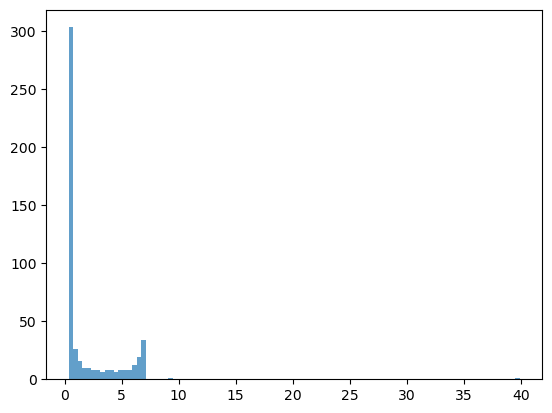

In [ ]:
sig_theta =0.05
averaging = 1000
blocksize = 100

dtheta = 3 # in degrees

fr, ctr,eval_f, eval_c, overlap_c, overlap_f, eval_chi_fr, eval_chi_ctr = compare_ctr_fr_quadratic_L_sharedbasis(
        N=N, J=W, T=T,
        c_ctr=c_ctr,
        c_fr=c_fr,b=b, I=I, eta_std=eta_std, sigma0=sigma0, u0=u0, du=du, db=db,
        theta_ctr=theta_base,
        theta_fr=theta_base,
        width=width, amp=amp,
        center1=N//2, center2=N//2+N*dtheta/360, Q=Q,
        sig_theta=sig_theta,
        L=averaging,
        tau_theta_trials=blocksize,
        device="cpu",
    )

# plt.plot(np.cumsum(eval_c[:]),np.cumsum(overlap_c[:]), marker='o', label="CTR")
# plt.plot(np.cumsum(eval_f[:]),np.cumsum(overlap_f[:]), marker='s', label="FR")

# plt.plot(np.array(eval_c[:]),np.array(overlap_c[:]), marker='o', label="CTR")
# plt.plot(np.array(eval_f[:]),np.array(overlap_f[:]), marker='s', label="FR")
plt.hist(eval_chi_fr, bins=100, alpha=0.7, label="FR eval chi")
# plt.plot(np.cumsum(eval_c[:]),np.cumsum(ctr[:]), marker='o', label="CTR")
# plt.plot(np.cumsum(eval_f[:]),np.cumsum(fr[:]), marker='s', label="FR")
# plt.plot((ctr[:]), marker='o', label="CTR")
# plt.plot((fr[:]), marker='s', label="FR")

# plt.axvline(x = k_top,color = 'k', linestyle = '--', alpha =0.5)
fac = 0.0#mean_variance_factor_correlated_trials(averaging, blocksize, device="cpu")
# print(fac)
A = 1
B = 5
# plt.plot((c_ctr**2 * eval_chi_ctr)/(A*(c_ctr**2 * eval_chi_ctr) + B), label="CTR")
# plt.plot((c_fr**2 * eval_chi_fr)/(A*(c_fr**2 * eval_chi_fr) + B), label="FR")

# plt.plot((sig_theta*c_ctr*eval_chi_ctr)**2*(fac/averaging)+T*eval_chi_ctr**2/averaging,(c_ctr*eval_chi_ctr))
# plt.plot((sig_theta*c_fr*eval_chi_fr)**2*(fac/averaging)+T*eval_chi_fr**2/averaging,(c_fr*eval_chi_fr))
# plt.yscale("log")
# plt.legend()

k_top = 15
ratio_topk_shared = float((fr[:k_top] / (ctr[:k_top] + 1e-12)).mean().item())
print(f"Ratio of mean SNR in top {k_top} modes (FR/CTR): {ratio_topk_shared:.3f}")
ratio_bottomN_K = float((fr[-k_top:] / (ctr[-k_top:] + 1e-12)).mean().item())
print(f"Ratio of mean SNR in bottom {k_top} modes (FR/CTR): {ratio_bottomN_K:.3f}")
total_ratio = float((fr.sum() / (ctr.sum() + 1e-12)).item())
print(f"Ratio of total SNR (FR/CTR): {total_ratio:.3f}")

# plot horizontal line at 90,80,70,60 percent performance if SNR is binary task
# plt.axhline(3.285, ls='--', color='k', alpha=0.7, label='90% performance')
# plt.axhline(1.4167, ls='--', color='k', alpha=0.7, label='80% performance')
# plt.axhline(0.55, ls='--', color='k', alpha=0.7, label='70% performance')
# plt.axhline(0.1285, ls='--', color='k', alpha=0.7, label='60% performance')


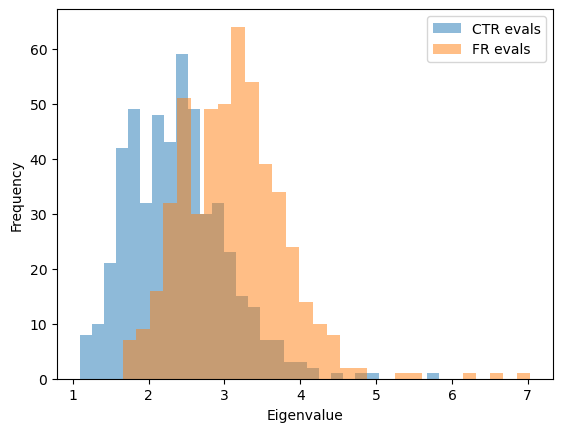

1.0888806581497192 5.835306167602539


In [259]:
plt.hist(eval_chi_ctr.cpu().numpy(), bins=30, alpha=0.5, label="CTR evals")
plt.hist(eval_chi_fr.cpu().numpy(), bins=30, alpha=0.5, label="FR evals")
plt.xlabel("Eigenvalue")
plt.ylabel("Frequency")
plt.legend()
plt.show()
print(min(eval_chi_ctr).item(), max(eval_chi_ctr).item())




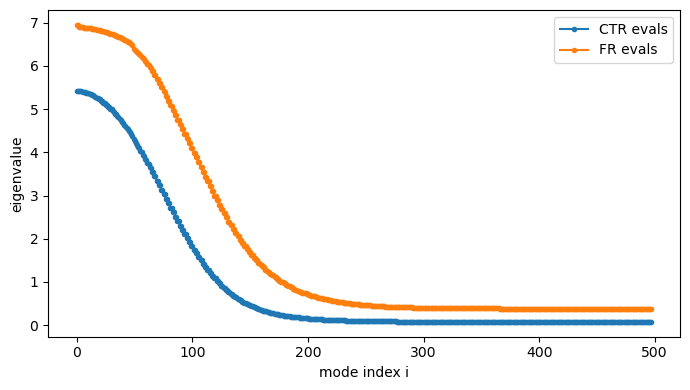

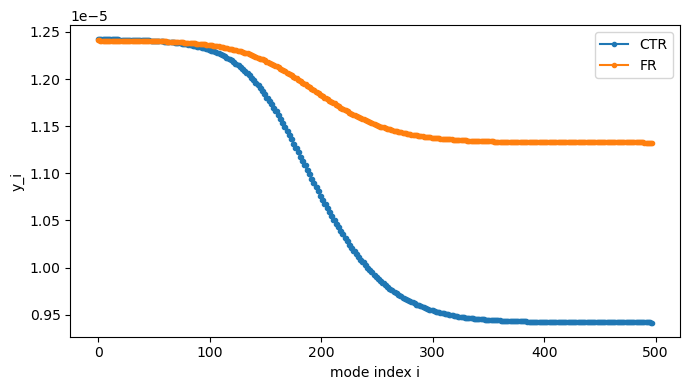

In [47]:
# Example: start from a realistic bulk
bulk_ctr = np.sort(np.asarray(eval_chi_ctr))[::-1]
bulk_fr  = np.sort(np.asarray(eval_chi_fr))[::-1]


eval_ctr = bulk_ctr#np.sort(np.concatenate([top_ctr, bulk_ctr]))[::-1]
eval_fr  = bulk_fr#np.sort(np.concatenate([top_fr,  bulk_fr ]))[::-1]
dx =0.0001
averaging = 500
blocksize = 100
sig_theta = 0.05
fac = mean_variance_factor_correlated_trials(averaging, blocksize, device="cpu")
B = (fac/averaging)
C = T/averaging

y_snr_fr = dx**2/(B*(sig_theta**2) + C/(eval_fr*(c_fr**2)))
y_snr_ctr = dx**2/(B*(sig_theta**2) + C/(eval_ctr*(c_ctr**2)))

total_cov_fr = B*(0.8*sig_theta*eval_fr)**2+C*eval_fr
total_cov_ctr = B*(sig_theta*eval_ctr)**2+C*eval_ctr




# rng = np.random.default_rng(seed=42)
# n_top = 50
# top_ctr = rng.normal(loc=500.0, scale=1, size=n_top)
# top_fr  = rng.normal(loc=500.0, scale=1, size=n_top)   # same top shelf by eye
# eval_ctr = np.sort(np.concatenate([top_ctr, bulk_ctr]))[::-1]
# eval_fr  = np.sort(np.concatenate([top_fr,  bulk_fr ]))[::-1]
# A = 0.0001
# B = 0.01
# C_ctr = 0.1

# C_fr = C_ctr/(0.8**2)
# y_snr_ctr = A/(B + C_ctr/eval_ctr)
# y_snr_fr  = A/(B + C_fr/eval_fr)

# C_over_B = C_ctr / B
# print(f"C/B ratio: {C_over_B:.3f}")

# total_cov_fr = B*(0.8*eval_fr)**2+C_fr*eval_fr
# total_cov_ctr = B*(eval_ctr)**2+C_ctr*eval_ctr
eval_ctr = np.copy(eval_ctr)[2:]   
eval_fr  = np.copy(eval_fr)[2:]
y_snr_ctr  = np.copy(y_snr_ctr)[2:]
y_snr_fr  = np.copy(y_snr_fr)[2:]
total_cov_ctr = np.copy(total_cov_ctr)[2:]
total_cov_fr = np.copy(total_cov_fr)[2:]

plt.figure(figsize=(7,4))
plt.plot(eval_ctr, 'o-', ms=3, label='CTR evals')
plt.plot(eval_fr, 'o-', ms=3, label='FR evals')
# plt.axvline(n_top-0.5, color='k', ls='--', alpha=0.4)
plt.legend()
plt.xlabel("mode index i")
plt.ylabel("eigenvalue")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(y_snr_ctr, 'o-', ms=3, label='CTR')
plt.plot(y_snr_fr, 'o-', ms=3, label='FR')
# plt.axvline(n_top-0.5, color='k', ls='--', alpha=0.4)
plt.legend()
plt.xlabel("mode index i")
plt.ylabel("y_i")
plt.tight_layout()
plt.show()

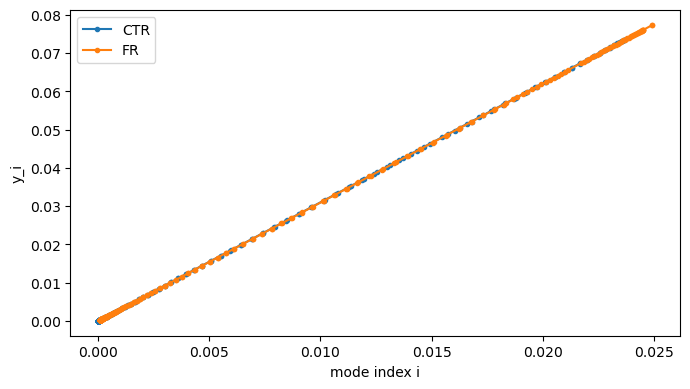

Sum of y for CTR: 1319.953
Sum of y for FR:  1463.734


In [41]:
plt.figure(figsize=(7,4))

plt.plot(total_cov_ctr, y_snr_ctr*(total_cov_ctr), 'o-', ms=3, label='CTR')
plt.plot(total_cov_fr, y_snr_fr*(total_cov_fr), 'o-', ms=3, label='FR')
plt.legend()
plt.xlabel("mode index i")
plt.ylabel("y_i")
plt.tight_layout()
plt.show()
# print sum of y
print(f"Sum of y for CTR: {y_snr_ctr.sum():.3f}")
print(f"Sum of y for FR:  {y_snr_fr.sum():.3f}")

(array([499.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.]),
 array([4.55197260e-05, 4.58751656e-02, 9.17048156e-02, 1.37534454e-01,
        1.83364108e-01, 2.29193762e-01, 2.75023371e-01, 3.20853025e-01,
        3.66682678e-01, 4.12512332e-01, 4.58341986e-01]),
 <BarContainer object of 10 artists>)

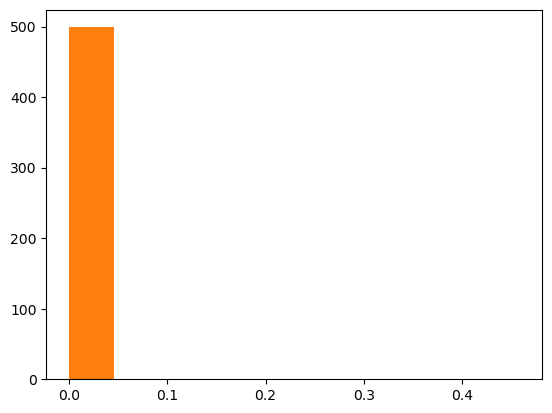

In [42]:
plt.hist(eval_c)
plt.hist(eval_f)
# plt.hist(total_cov_ctr)
# plt.hist(total_cov_fr)

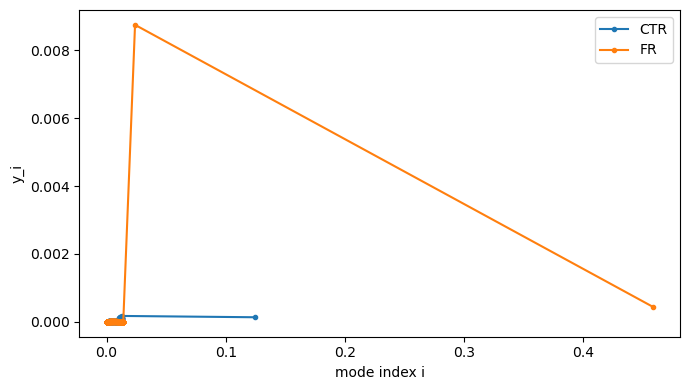

NameError: name 'y_ctr' is not defined

In [43]:
plt.figure(figsize=(7,4))
total_cov_fr = B*eval_fr**2+0.1*eval_fr
total_cov_ctr = B*eval_ctr**2+0.1*eval_ctr
plt.plot(eval_c, ctr*(eval_c), 'o-', ms=3, label='CTR')
plt.plot(eval_f, fr*(eval_f), 'o-', ms=3, label='FR')
plt.legend()
plt.xlabel("mode index i")
plt.ylabel("y_i")
plt.tight_layout()
plt.show()
# print sum of y
print(f"Sum of y for CTR: {y_ctr.sum():.3f}")
print(f"Sum of y for FR:  {y_fr.sum():.3f}")

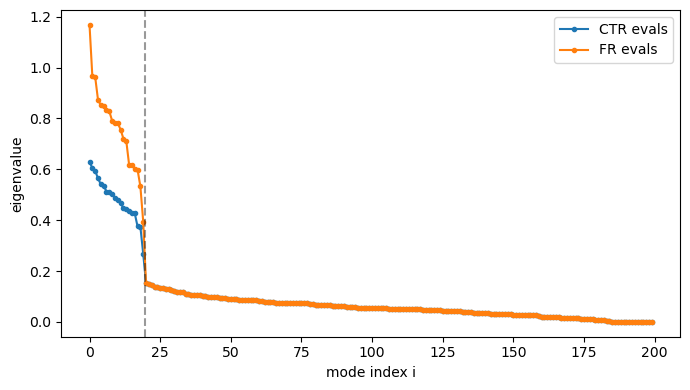

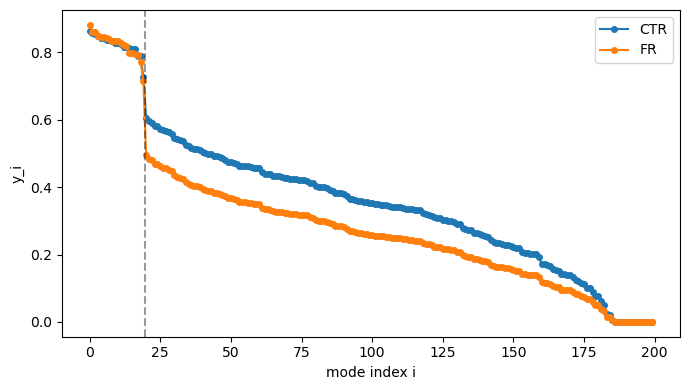

In [72]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

# --------------------------------------------------
# Map y = A / (B + C/lambda)
# --------------------------------------------------
def mode_function(evals, A=1.0, B=1.0, C=0.1, eps=1e-12):
    evals = np.clip(np.asarray(evals, dtype=float), eps, None)
    return A / (B + C / evals)

# --------------------------------------------------
# Build fake eigenvalue spectra
# --------------------------------------------------
def make_bulk(N_bulk, bulk_top=2.8, bulk_floor=0.25, tau=45, noise_std=0.03):
    k = np.arange(N_bulk)
    bulk = bulk_floor + (bulk_top - bulk_floor) * np.exp(-k / tau)
    bulk += rng.normal(0, noise_std, size=N_bulk)
    bulk = np.clip(bulk, 1e-6, None)
    return bulk

N = 200
n_plateau = 20
N_bulk = N - n_plateau

# Parameters in y = A / (B + C/lambda)
A_num = 1.0
B_den = 1.0

C_ctr = 0.10
C_fr  = 0.10 / (0.8**2)   # = 0.15625

# -----------------------------------------
# Top 20 outliers:
# make FR larger so the mapped plateau matches CTR
# -----------------------------------------
top_ctr_mean = 0.5
top_ctr_std  = 0.1

top_ctr = rng.normal(top_ctr_mean, top_ctr_std, size=n_plateau)

# Match finite top values by scaling with C_fr/C_ctr
match_factor = C_fr / C_ctr   # 1.5625 here
top_fr = top_ctr * match_factor + rng.normal(0, 0.15, size=n_plateau)

# -----------------------------------------
# Bulk:
# FR lower / faster decay than CTR
# -----------------------------------------
bulk_ctr = make_bulk(
    N_bulk,
    bulk_top=0.1,
    bulk_floor=0.01,
    tau=100,
    noise_std=0.03
)
bulk_fr = bulk_ctr

# Full spectra

eval_ctr = np.sort(np.concatenate([top_ctr, bulk_ctr]))[::-1]
eval_fr  = np.sort(np.concatenate([top_fr,  bulk_fr]))[::-1]

# Map to y_i
y_ctr = mode_function(eval_ctr, A=A_num, B=B_den, C=C_ctr)
y_fr  = mode_function(eval_fr,  A=A_num, B=B_den, C=C_fr)

# --------------------------------------------------
# Plot eigenvalues
# --------------------------------------------------
plt.figure(figsize=(7,4))
plt.plot(eval_ctr, marker='o', ms=3, label='CTR evals')
plt.plot(eval_fr, marker='o', ms=3, label='FR evals')
plt.axvline(n_plateau - 0.5, color='k', ls='--', alpha=0.4)
plt.xlabel("mode index i")
plt.ylabel("eigenvalue")
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Plot mapped y_i
# --------------------------------------------------
plt.figure(figsize=(7,4))
plt.plot(y_ctr, marker='o', ms=4, label='CTR')
plt.plot(y_fr, marker='o', ms=4, label='FR')
plt.axvline(n_plateau - 0.5, color='k', ls='--', alpha=0.4)
plt.xlabel("mode index i")
plt.ylabel("y_i")
plt.legend()
plt.tight_layout()
plt.show()

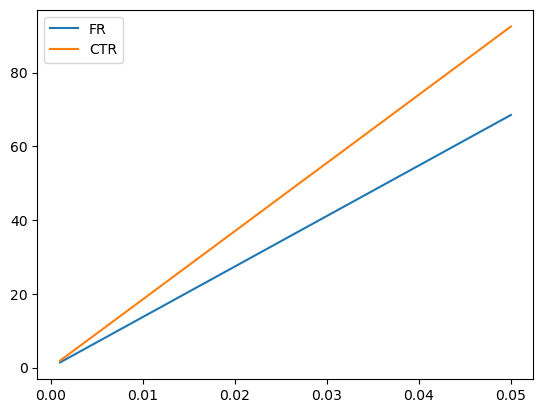

In [25]:
# plt.axhline(3.285, ls='--', color='b', alpha=0.7, label='90% performance')
# plt.axhline(1.4167, ls='--', color='g', alpha=0.7, label='80% performance')
# plt.axhline(0.55, ls='--', color='y', alpha=0.7, label='70% performance')
# plt.axhline(0.1285, ls='--', color='r', alpha=0.7, label='60% performance')
# dx = 0.01
# A = 1
# B = 0.05
# c_fr = 0.8
# plt.plot(np.cumsum(dx/(A+B/((c_ctr**2)*eval_fake))), label="CTR")
# plt.plot(np.cumsum(dx/(A+B/((c_fr**2)*eval_fakefr))), label="FR")

# dx = 0.001


# plt.plot(np.cumsum(dx/(A+B/((c_ctr**2)*eval_fake))), label="CTR")
# plt.plot(np.cumsum(dx/(A+B/((c_fr**2)*eval_fakefr))), label="FR")


from scipy.stats import norm



def snr_to_accuracy(snrval):
    dprime = np.sqrt(snrval)
    z = dprime / np.sqrt(2)
    perf = norm.cdf(z)
    return snrval
def testfig(A,B,c,evals,dx):
    result = dx/(A+B/((c**2)*evals))
    return result

A = 0.1
B = 0.5
c_fr = 0.8
c_ctr = 1
evals = eval_fakefr
dxs = np.linspace(0.001, 0.05, 100)
results_fr = []
results_ctr = []
for dx in dxs:
    result_ctr = testfig(A,B,c_ctr,evals,dx).sum().item()
    results_ctr.append(snr_to_accuracy(result_ctr))
    result_fr = testfig(A,B,c_fr,evals,dx).sum().item()
    results_fr.append(snr_to_accuracy(result_fr))

plt.plot(dxs, results_fr, label="FR")
plt.plot(dxs, results_ctr, label="CTR")
plt.legend()
plt.show()


In [30]:
fac = mean_variance_factor_correlated_trials(averaging, blocksize, device="cpu")
lam_star_ctr = T / (fac * sig_theta**2 * c_ctr**2)
lam_star_fr  = T / (fac * sig_theta**2 * c_fr**2)

print("fac =", fac)
print("lambda*_ctr =", lam_star_ctr)
print("lambda*_fr  =", lam_star_fr)
print("frac ctr above crossover =", np.mean(eval_ctr > lam_star_ctr))
print("frac fr above crossover  =", np.mean(eval_fr  > lam_star_fr))


fac = 160.27151489257812
lambda*_ctr = 0.07487294300576736
lambda*_fr  = 0.11698897344651149
frac ctr above crossover = 1.0
frac fr above crossover  = 1.0


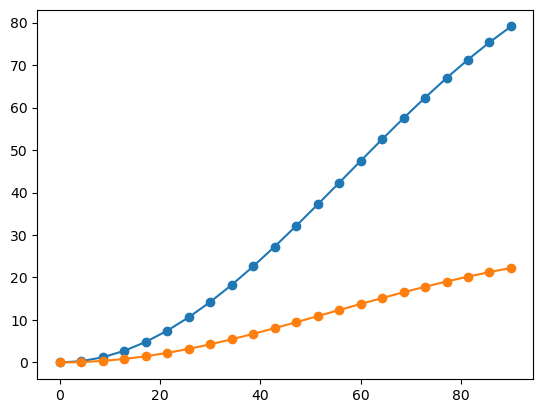

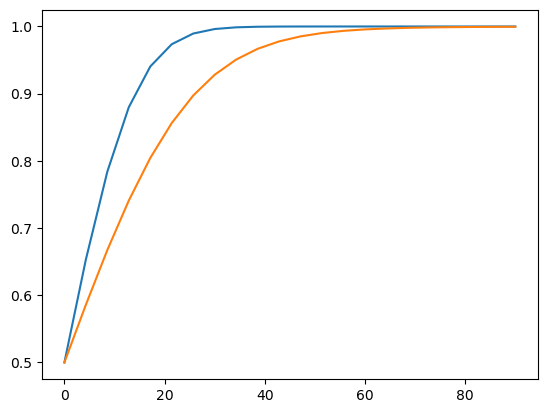

In [42]:
from scipy.stats import norm 
snr_ctr_dtheta = []
snr_fr_dtheta = []
number_samples = 90
dtheta_vals = np.linspace(0,N//4,number_samples//4, endpoint=True)
averaging = 50
blocksize = 10
sig_theta = 0.01
c_fr = 0.5
for dtheta in dtheta_vals:
    fr, ctr,_,_,_,_,_,_ = compare_ctr_fr_quadratic_L_sharedbasis(
        N=N, J=W, T=T,
        c_ctr=c_ctr,
        c_fr=c_fr,b=b, I=I, eta_std=eta_std, sigma0=sigma0, u0=u0, du=du, db=db,
        theta_ctr=theta_base,
        theta_fr=theta_base,
        width=width, amp=amp,
        center1=N//2, center2=N//2+dtheta, Q=Q,
        sig_theta=sig_theta,
        L=averaging,
        tau_theta_trials=blocksize,
        device="cpu",
    )
    snr_ctr_dtheta.append(ctr.sum())
    snr_fr_dtheta.append(fr.sum())


x_values = dtheta_vals*360/N

plt.plot(x_values,snr_ctr_dtheta, 'o-')
plt.plot(x_values,snr_fr_dtheta,'o-')
plt.show()

def snr_to_accuracy(snrval):
    dprime = np.sqrt(snrval)
    z = dprime / np.sqrt(2)
    perf = norm.cdf(z)
    return perf
plt.plot(x_values,snr_to_accuracy(snr_ctr_dtheta))
plt.plot(x_values,snr_to_accuracy(snr_fr_dtheta))





# Multiple angles

Stored multi-angle arrays with shape (500, 500) at fixed dtheta=50.000 deg.
center1_deg spans 0.000 to 359.280 deg.


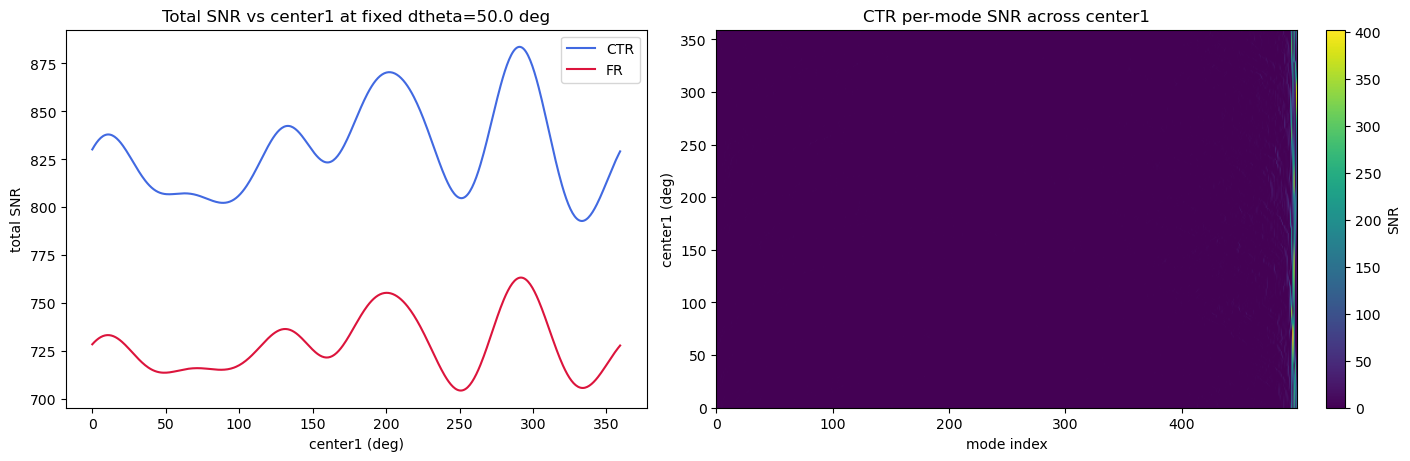

In [55]:
def _to_numpy_cpu(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


center1_vals = np.arange(N)
dtheta_offset = N * dtheta / 360.0
center2_vals = np.mod(center1_vals + dtheta_offset, N)
center1_deg = center1_vals * 360.0 / N

snr_ctr_rows = []
snr_fr_rows = []
overlap_ctr_rows = []
overlap_fr_rows = []
eval_chi_ctr_rows = []
eval_chi_fr_rows = []

for center1_val, center2_val in zip(center1_vals, center2_vals):
    snr_fr, snr_ctr, _, _, overlap_ctr, overlap_fr, eval_chi_fr, eval_chi_ctr = compare_ctr_fr_quadratic_L_sharedbasis(
        N=N, J=W, T=T,
        c_ctr=c_ctr,
        c_fr=c_fr, b=b, I=I, eta_std=eta_std, sigma0=sigma0, u0=u0, du=du, db=db,
        theta_ctr=theta_base,
        theta_fr=theta_base,
        width=width, amp=amp,
        center1=center1_val, center2=center2_val, Q=Q,
        sig_theta=sig_theta,
        L=averaging,
        tau_theta_trials=blocksize,
        device="cpu",
    )
    snr_ctr_rows.append(_to_numpy_cpu(snr_ctr))
    snr_fr_rows.append(_to_numpy_cpu(snr_fr))
    overlap_ctr_rows.append(_to_numpy_cpu(overlap_ctr))
    overlap_fr_rows.append(_to_numpy_cpu(overlap_fr))
    eval_chi_ctr_rows.append(_to_numpy_cpu(eval_chi_ctr))
    eval_chi_fr_rows.append(_to_numpy_cpu(eval_chi_fr))

multi_angle_results = {
    "center1_vals": center1_vals,
    "center1_deg": center1_deg,
    "center2_vals": center2_vals,
    "dtheta_deg": float(dtheta),
    "snr_ctr": np.stack(snr_ctr_rows, axis=0),
    "snr_fr": np.stack(snr_fr_rows, axis=0),
    "overlap_ctr": np.stack(overlap_ctr_rows, axis=0),
    "overlap_fr": np.stack(overlap_fr_rows, axis=0),
    "eval_chi_ctr": np.stack(eval_chi_ctr_rows, axis=0),
    "eval_chi_fr": np.stack(eval_chi_fr_rows, axis=0),
}
multi_angle_results["snr_ctr_total"] = multi_angle_results["snr_ctr"].sum(axis=1)
multi_angle_results["snr_fr_total"] = multi_angle_results["snr_fr"].sum(axis=1)

reference_center1 = float(N // 2)
reference_center2 = float((reference_center1 + dtheta_offset) % N)
reference_outputs = compare_ctr_fr_quadratic_L_sharedbasis(
    N=N, J=W, T=T,
    c_ctr=c_ctr,
    c_fr=c_fr, b=b, I=I, eta_std=eta_std, sigma0=sigma0, u0=u0, du=du, db=db,
    theta_ctr=theta_base,
    theta_fr=theta_base,
    width=width, amp=amp,
    center1=reference_center1, center2=reference_center2, Q=Q,
    sig_theta=sig_theta,
    L=averaging,
    tau_theta_trials=blocksize,
    device="cpu",
)
reference_idx = int(reference_center1)
np.testing.assert_allclose(multi_angle_results["snr_fr"][reference_idx], _to_numpy_cpu(reference_outputs[0]))
np.testing.assert_allclose(multi_angle_results["snr_ctr"][reference_idx], _to_numpy_cpu(reference_outputs[1]))
np.testing.assert_allclose(multi_angle_results["overlap_ctr"][reference_idx], _to_numpy_cpu(reference_outputs[4]))
np.testing.assert_allclose(multi_angle_results["overlap_fr"][reference_idx], _to_numpy_cpu(reference_outputs[5]))
np.testing.assert_allclose(multi_angle_results["eval_chi_fr"][reference_idx], _to_numpy_cpu(reference_outputs[6]))
np.testing.assert_allclose(multi_angle_results["eval_chi_ctr"][reference_idx], _to_numpy_cpu(reference_outputs[7]))

expected_shape = (N, N)
for key in ["snr_ctr", "snr_fr", "overlap_ctr", "overlap_fr", "eval_chi_ctr", "eval_chi_fr"]:
    assert multi_angle_results[key].shape == expected_shape, f"{key} shape mismatch: {multi_angle_results[key].shape}"
    assert np.isfinite(multi_angle_results[key]).all(), f"{key} contains non-finite values"

wrapped_offsets = np.mod(multi_angle_results["center2_vals"] - multi_angle_results["center1_vals"], N)
assert np.allclose(wrapped_offsets, dtheta_offset), "center2_vals does not preserve fixed wrapped dtheta offset"
assert np.allclose(multi_angle_results["snr_ctr_total"], multi_angle_results["snr_ctr"].sum(axis=1))
assert np.allclose(multi_angle_results["snr_fr_total"], multi_angle_results["snr_fr"].sum(axis=1))
assert np.allclose(multi_angle_results["center1_deg"], multi_angle_results["center1_vals"] * 360.0 / N)

print(f"Stored multi-angle arrays with shape {multi_angle_results['snr_ctr'].shape} at fixed dtheta={dtheta:.3f} deg.")
print(f"center1_deg spans {multi_angle_results['center1_deg'][0]:.3f} to {multi_angle_results['center1_deg'][-1]:.3f} deg.")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
axes[0].plot(multi_angle_results["center1_deg"], multi_angle_results["snr_ctr_total"], label="CTR", color="royalblue")
axes[0].plot(multi_angle_results["center1_deg"], multi_angle_results["snr_fr_total"], label="FR", color="crimson")
axes[0].set_xlabel("center1 (deg)")
axes[0].set_ylabel("total SNR")
axes[0].set_title(f"Total SNR vs center1 at fixed dtheta={dtheta:.1f} deg")
axes[0].legend()

im = axes[1].imshow(
    multi_angle_results["snr_ctr"],
    aspect="auto",
    origin="lower",
    extent=[0, N - 1, center1_deg[0], center1_deg[-1]],
    cmap="viridis",
)
axes[1].set_xlabel("mode index")
axes[1].set_ylabel("center1 (deg)")
axes[1].set_title("CTR per-mode SNR across center1")
fig.colorbar(im, ax=axes[1], label="SNR")
plt.show()


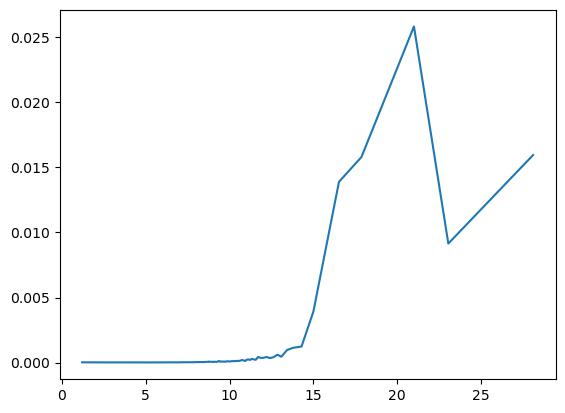

In [64]:
multi_angle_results["overlap_ctr"].shape
plt.plot(multi_angle_results["eval_chi_ctr"].mean(axis = 0)**2,multi_angle_results["overlap_ctr"].mean(axis = 0))